# 2D Convolutional Variational Autoencoder for EEG Wavelet Features

このnotebookでは、ウェーブレット変換されたEEGデータに対して2次元畳み込み層を使用したVariational Autoencoder (VAE)を適用し、特徴量抽出を行います。

ウェーブレット変換の結果は(scales, time)の2次元構造を保持し、2D CNNで処理します。

In [26]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import pywt
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing
import warnings
warnings.filterwarnings('ignore')

In [27]:
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## データの読み込みとウェーブレット変換

In [ ]:
# エポック別に保存されたウェーブレット変換済みデータの読み込み
import os
from pathlib import Path
from tqdm import tqdm

# ウェーブレット特徴量ディレクトリ
wavelet_dir = Path("../../data/bcidatasetIV2a/processed/wavelet_features_25hz")
# wavelet_dir = Path("../data/20250512/processed/wavelet_features")

# エポックファイルの数を確認
epoch_files = sorted(list(wavelet_dir.glob("epoch_*.pkl")))
n_epochs = len(epoch_files)
print(f"Found {n_epochs} epoch files")

# 最初のエポックを読み込んでデータ構造を確認
with open(epoch_files[0], 'rb') as f:
    sample_epoch = pickle.load(f)

print(f"Sample epoch data type: {type(sample_epoch)}")
if isinstance(sample_epoch, dict):
    print("Sample epoch data keys:", sample_epoch.keys())
    for key, value in sample_epoch.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {type(value)} - shape {value.shape}")
        else:
            print(f"  {key}: {type(value)}")
else:
    print(f"Sample epoch data shape: {sample_epoch.shape}")

# ラベルデータを別途読み込み（元のエポックデータから）
original_data_path = Path("../data/20250512/processed/ishii_merged.pkl")
with open(original_data_path, 'rb') as f:
    original_data = pickle.load(f)
labels = original_data['labels']

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")

Found 160 epoch files
Sample epoch data type: <class 'numpy.ndarray'>
Sample epoch data shape: (31, 1, 63, 150)
Labels shape: (160,)
Unique labels: [   1    2    3 9999]


In [ ]:
# エポック別ウェーブレットデータを順次読み込み、メモリ効率的に処理（2D構造保持）
def load_wavelet_data_incrementally_2d(epoch_files, batch_size=100):
    """
    エポック別ウェーブレットデータを小バッチずつ読み込み
    2D構造（channels, scales, times）を保持
    """
    all_data = []
    metadata = None
    
    print(f"Loading {len(epoch_files)} epochs in batches of {batch_size}...")
    
    for i in tqdm(range(0, len(epoch_files), batch_size), desc="Loading batches"):
        batch_files = epoch_files[i:i+batch_size]
        batch_data = []
        
        for epoch_file in batch_files:
            with open(epoch_file, 'rb') as f:
                epoch_data = pickle.load(f)
                
                if isinstance(epoch_data, dict):
                    # 辞書形式の場合、ウェーブレット係数を取得
                    if 'coefficients' in epoch_data:
                        wavelet_coeffs = epoch_data['coefficients']
                    elif 'wavelet_coeffs' in epoch_data:
                        wavelet_coeffs = epoch_data['wavelet_coeffs']
                    else:
                        # 最初のarray要素を取得
                        wavelet_coeffs = list(epoch_data.values())[0]
                    
                    # メタデータを保存（最初のエポックから）
                    if metadata is None:
                        metadata = {k: v for k, v in epoch_data.items() if k not in ['coefficients', 'wavelet_coeffs']}
                else:
                    # 直接arrayの場合
                    wavelet_coeffs = epoch_data
                
                batch_data.append(wavelet_coeffs)
        
        # バッチを結合
        if batch_data:
            batch_array = np.stack(batch_data, axis=0)
            # 5次元データの場合、中間の1次元を削除して4次元にする
            if len(batch_array.shape) == 5 and batch_array.shape[2] == 1:
                batch_array = batch_array.squeeze(2)  # (epochs, channels, 1, scales, times) -> (epochs, channels, scales, times)
                print(f"Batch {i//batch_size + 1}: loaded {len(batch_data)} epochs, reshaped to: {batch_array.shape}")
            else:
                print(f"Batch {i//batch_size + 1}: loaded {len(batch_data)} epochs, shape: {batch_array.shape}")
            all_data.append(batch_array)
    
    # すべてのバッチを結合
    if all_data:
        final_data = np.concatenate(all_data, axis=0)
        print(f"Final concatenated shape: {final_data.shape}")
        return final_data, metadata
    else:
        return None, None

# ウェーブレットデータを読み込み（2D構造保持）
wavelet_coeffs, wavelet_metadata = load_wavelet_data_incrementally_2d(epoch_files[:min(1600, len(epoch_files))])  # 最初の1600エポックを使用

if wavelet_coeffs is not None:
    print(f"Loaded wavelet coefficients shape: {wavelet_coeffs.shape}")
    
    # ラベルをエポック数に合わせて調整
    labels = labels[:wavelet_coeffs.shape[0]]
    print(f"Adjusted labels shape: {labels.shape}")
    
    # データ形状情報を取得（2D構造を保持）
    if len(wavelet_coeffs.shape) == 4:
        n_epochs, n_channels, n_scales, n_times = wavelet_coeffs.shape
        print(f"Data dimensions: epochs={n_epochs}, channels={n_channels}, scales={n_scales}, times={n_times}")
    else:
        raise ValueError(f"Unexpected data shape for 2D convolution: {wavelet_coeffs.shape}")
    
    print(f"2D convolution input shape per epoch: (channels={n_channels}, scales={n_scales}, times={n_times})")
    
    # データの正規化（チャンネル別に正規化）
    # 各チャンネルを独立して正規化
    X_normalized = np.zeros_like(wavelet_coeffs)
    for ch in range(n_channels):
        ch_data = wavelet_coeffs[:, ch, :, :].reshape(n_epochs, -1)
        scaler = StandardScaler()
        ch_normalized = scaler.fit_transform(ch_data)
        X_normalized[:, ch, :, :] = ch_normalized.reshape(n_epochs, n_scales, n_times)
    
    print(f"正規化後のデータ範囲: 最小値={X_normalized.min():.4f}, 最大値={X_normalized.max():.4f}")
    
    # 訓練・検証・テストセットに分割
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_normalized, labels, test_size=0.4, random_state=42, stratify=labels
    )
    X_val, X_test, y_val, y_test = X_temp, X_temp, y_temp, y_temp
    
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    print("2D data loading and preprocessing completed successfully!")
else:
    print("Failed to load wavelet data")

Loading 160 epochs in batches of 100...


Loading batches:  50%|█████     | 1/2 [00:02<00:02,  2.27s/it]

Batch 1: loaded 100 epochs, reshaped to: (100, 31, 63, 150)


Loading batches: 100%|██████████| 2/2 [00:02<00:00,  1.33s/it]

Batch 2: loaded 60 epochs, reshaped to: (60, 31, 63, 150)


Final concatenated shape: (160, 31, 63, 150)
Loaded wavelet coefficients shape: (160, 31, 63, 150)
Adjusted labels shape: (160,)
Data dimensions: epochs=160, channels=31, scales=63, times=150
2D convolution input shape per epoch: (channels=31, scales=63, times=150)
正規化後のデータ範囲: 最小値=-2.0739, 最大値=12.6002
正規化後のデータ範囲: 最小値=-2.0739, 最大値=12.6002
Training set shape: (96, 31, 63, 150)
Validation set shape: (32, 31, 63, 150)
Test set shape: (32, 31, 63, 150)
2D data loading and preprocessing completed successfully!
Training set shape: (96, 31, 63, 150)
Validation set shape: (32, 31, 63, 150)
Test set shape: (32, 31, 63, 150)
2D data loading and preprocessing completed successfully!


## 2D Convolutional Variational Autoencoder モデル定義

In [30]:
class Conv2DVAE(nn.Module):
    def __init__(self, n_channels=22, n_scales=63, n_times=60, latent_dim=128):
        super(Conv2DVAE, self).__init__()
        
        self.n_channels = n_channels
        self.n_scales = n_scales
        self.n_times = n_times
        self.latent_dim = latent_dim
        
        # Encoder - 2D畳み込み層でウェーブレット特徴量を処理
        self.encoder = nn.Sequential(
            # 入力: (batch, n_channels, n_scales, n_times)
            nn.Conv2d(n_channels, 64, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            
            # (batch, 64, n_scales, n_times//2)
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            
            # (batch, 128, n_scales//2, n_times//4)
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            
            # (batch, 256, n_scales//4, n_times//8)
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout2d(0.2),
        )
        
        # エンコーダ出力サイズを計算
        with torch.no_grad():
            dummy_input = torch.zeros(1, n_channels, n_scales, n_times)
            encoded_output = self.encoder(dummy_input)
            self.encoded_size = encoded_output.numel()
            self.encoded_shape = encoded_output.shape[1:]
            print(f"Encoder output shape: {encoded_output.shape}")
            print(f"Encoded size: {self.encoded_size}")
        
        # 潜在変数の平均と分散を出力する全結合層
        self.fc_mu = nn.Linear(self.encoded_size, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_size, latent_dim)
        
        # Decoderの最初の全結合層
        self.fc_decode = nn.Linear(latent_dim, self.encoded_size)
        
        # Decoder - 2D転置畳み込み層（適切なoutput_paddingで元のサイズに復元）
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            
            nn.ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            
            nn.ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            
            # 最後の層で正確な出力サイズを指定
            nn.ConvTranspose2d(64, n_channels, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1), output_padding=(0, 0)),
        )
        
        # 最終的なサイズ調整層（必要に応じて）
        self.final_adjust = nn.AdaptiveAvgPool2d((n_scales, n_times))
        
        # 出力層（Sigmoidで0-1範囲に制限）
        self.output_activation = nn.Sigmoid()
    
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # フラット化
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, *self.encoded_shape)  # エンコーダ出力の形状に復元
        h = self.decoder(h)
        
        # サイズが正確でない場合は調整
        if h.shape[2:] != (self.n_scales, self.n_times):
            h = self.final_adjust(h)
        
        return self.output_activation(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z

def conv2d_vae_loss(recon_x, x, mu, logvar, beta=1.0, reduction='sum'):
    """
    2D Conv VAE損失関数
    """
    # 再構成誤差（MSE）
    if reduction == 'sum':
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    else:
        recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KLダイバージェンス
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

## チャンネルの扱いについて

### 入力データの構造
現在のモデルでは、EEGデータは以下の4次元構造で扱われています：
- **バッチ次元**: サンプル数
- **チャンネル次元**: 22個のEEGセンサー（入力チャンネル）
- **スケール次元**: 63個のウェーブレット周波数スケール
- **時間次元**: 60時間点

### チャンネル処理の流れ

1. **入力層でのチャンネル変換**:
   ```python
   nn.Conv2d(n_channels=22, out_channels=64, kernel_size=(3,3))
   ```
   - 22個の物理的EEGチャンネルを64個の特徴チャンネルに変換
   - 各出力チャンネルは、全ての入力チャンネルの重み付き組み合わせ

2. **空間的特徴の学習**:
   - 畳み込み層は、異なるEEGセンサー間の空間的関係を学習
   - 例：C3, C4, Czなどの運動野周辺の電極間の相互作用

3. **チャンネル数の段階的増加**:
   - 第1層: 22 → 64チャンネル
   - 第2層: 64 → 128チャンネル  
   - 第3層: 128 → 256チャンネル
   - 第4層: 256 → 512チャンネル

### 各畳み込み層でのチャンネル処理

**第1層の詳細**:
- 入力: `(batch, 22, 63, 60)`
- カーネル: `(64, 22, 3, 3)` - 64個の3×3フィルタ、各フィルタが22チャンネル全てを処理
- 出力: `(batch, 64, 63, 30)`

**チャンネル間の相互作用**:
- 各出力特徴マップは、全入力チャンネルの重み付き和
- これにより、異なるEEG電極間の空間的パターンを学習
- 運動想像時の特徴的な脳活動パターン（ERD/ERS）を捉える

## Encoderにおける次元変化の詳細解析

### 次元の種類

1. **チャンネル次元** (Feature channels): 特徴の種類数
2. **空間次元** (Spatial dimensions): データのサイズ（高さ×幅）
3. **総次元数** = チャンネル数 × 空間サイズ

### Encoderでの実際の変化

```
入力: (22, 63, 60) = 82,920 次元
↓
第1層: (64, 63, 30) = 120,960 次元  ← チャンネル↑、空間↓
↓
第2層: (128, 32, 15) = 61,440 次元  ← チャンネル↑、空間↓↓
↓
第3層: (256, 16, 8) = 32,768 次元   ← チャンネル↑、空間↓↓↓
↓
第4層: (512, 8, 4) = 16,384 次元    ← チャンネル↑、空間↓↓↓↓
↓
潜在変数: (128,) = 128 次元          ← 大幅な次元削減！
```

In [31]:
# Encoderでの次元変化を詳細に分析
def analyze_encoder_dimensions():
    """
    Encoderの各層での次元変化を詳細に分析
    """
    print("=== Encoderにおける次元変化の詳細分析 ===\n")
    
    # 入力データの次元
    input_shape = (22, 63, 60)
    input_total_dims = np.prod(input_shape)
    
    print(f"📊 入力データ:")
    print(f"   形状: {input_shape}")
    print(f"   総次元数: {input_total_dims:,} 次元")
    print(f"   内訳: {input_shape[0]}チャンネル × {input_shape[1]}×{input_shape[2]}空間 = {input_total_dims:,}\n")
    
    # 各層での変化をシミュレート
    layers_info = [
        {"name": "第1層", "channels": 64, "spatial": (63, 30), "stride": (1, 2)},
        {"name": "第2層", "channels": 128, "spatial": (32, 15), "stride": (2, 2)},
        {"name": "第3層", "channels": 256, "spatial": (16, 8), "stride": (2, 2)},
        {"name": "第4層", "channels": 512, "spatial": (8, 4), "stride": (2, 2)},
    ]
    
    print("🔄 各層での変化:")
    prev_total = input_total_dims
    
    for layer in layers_info:
        channels = layer["channels"]
        spatial_h, spatial_w = layer["spatial"]
        total_dims = channels * spatial_h * spatial_w
        reduction_ratio = total_dims / prev_total
        
        print(f"   {layer['name']}: ({channels}, {spatial_h}, {spatial_w})")
        print(f"      総次元数: {total_dims:,} 次元")
        print(f"      前層比: {reduction_ratio:.3f}x ({'+' if reduction_ratio > 1 else ''}{(reduction_ratio-1)*100:.1f}%)")
        print(f"      チャンネル: ×{channels/22:.1f}, 空間: ×{(spatial_h*spatial_w)/(63*60):.3f}")
        print()
        
        prev_total = total_dims
    
    # 潜在変数への最終圧縮
    latent_dim = 128
    final_reduction = latent_dim / input_total_dims
    
    print(f"🎯 最終的な潜在変数:")
    print(f"   形状: ({latent_dim},)")
    print(f"   総次元数: {latent_dim} 次元")
    print(f"   圧縮率: {final_reduction:.6f}x")
    print(f"   削減率: {(1-final_reduction)*100:.3f}%")
    print(f"   圧縮比: {input_total_dims//latent_dim}:1")
    
    return layers_info

# 実行
layers_info = analyze_encoder_dimensions()

=== Encoderにおける次元変化の詳細分析 ===

📊 入力データ:
   形状: (22, 63, 60)
   総次元数: 83,160 次元
   内訳: 22チャンネル × 63×60空間 = 83,160

🔄 各層での変化:
   第1層: (64, 63, 30)
      総次元数: 120,960 次元
      前層比: 1.455x (+45.5%)
      チャンネル: ×2.9, 空間: ×0.500

   第2層: (128, 32, 15)
      総次元数: 61,440 次元
      前層比: 0.508x (-49.2%)
      チャンネル: ×5.8, 空間: ×0.127

   第3層: (256, 16, 8)
      総次元数: 32,768 次元
      前層比: 0.533x (-46.7%)
      チャンネル: ×11.6, 空間: ×0.034

   第4層: (512, 8, 4)
      総次元数: 16,384 次元
      前層比: 0.500x (-50.0%)
      チャンネル: ×23.3, 空間: ×0.008

🎯 最終的な潜在変数:
   形状: (128,)
   総次元数: 128 次元
   圧縮率: 0.001539x
   削減率: 99.846%
   圧縮比: 649:1


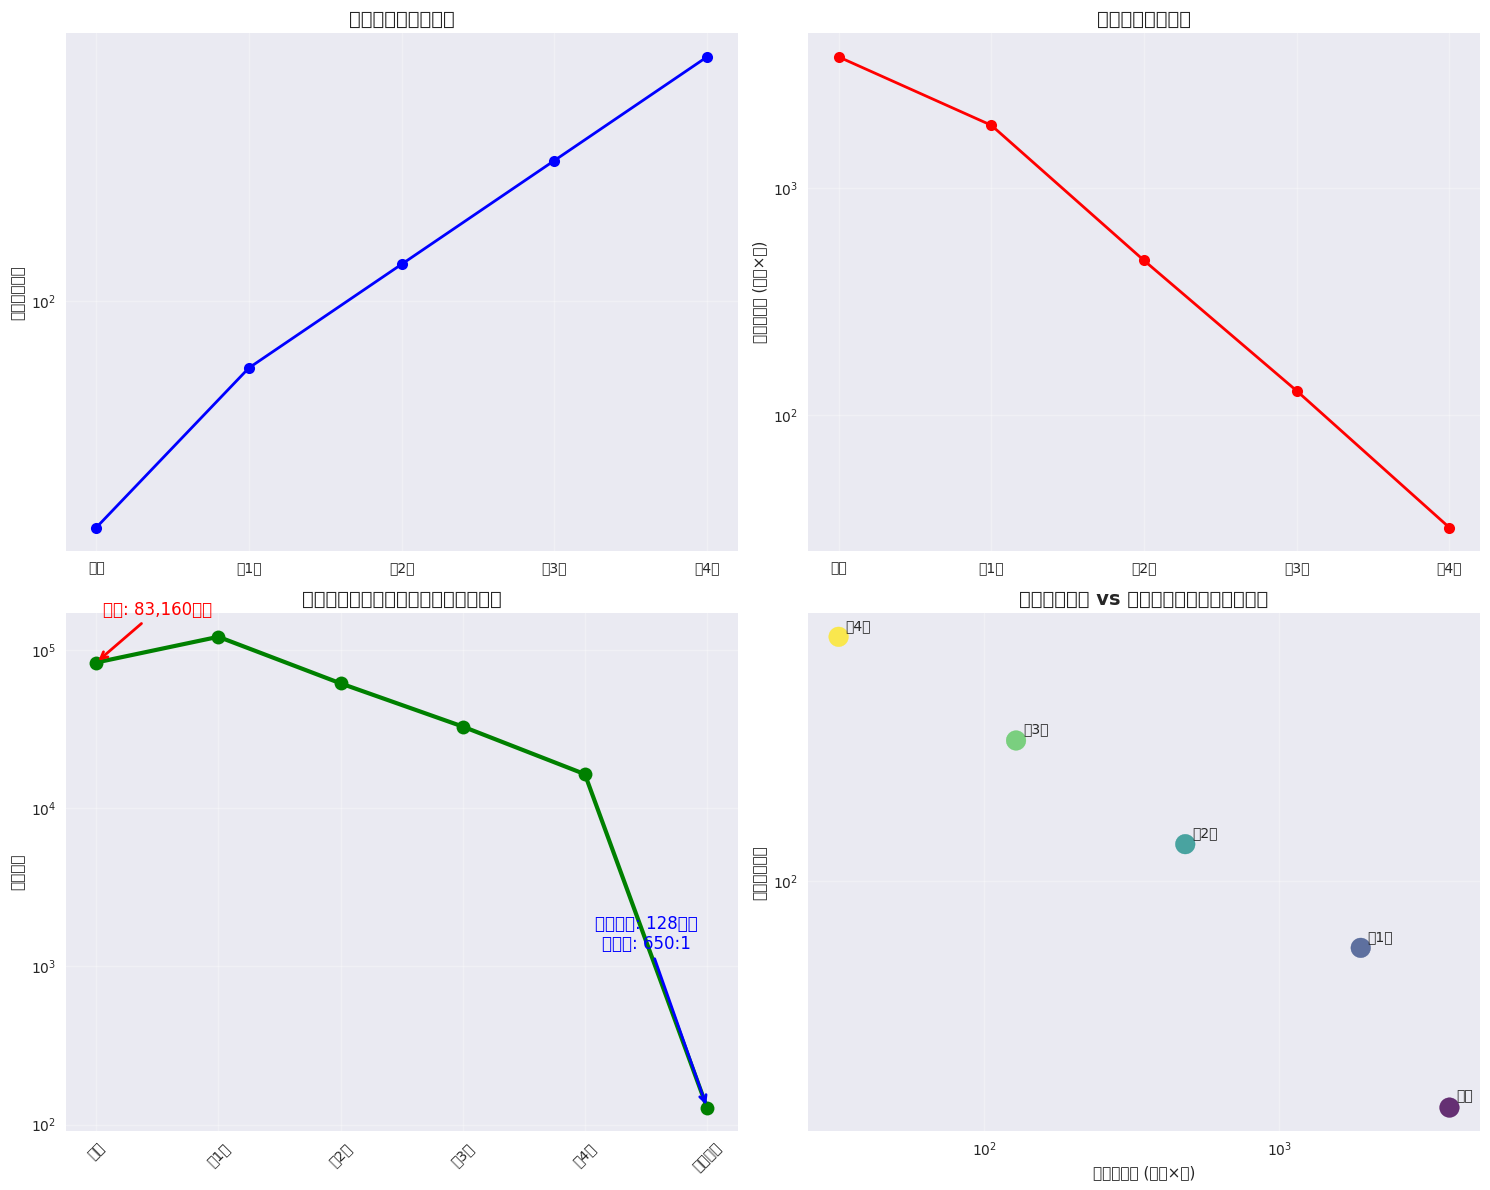


=== チャンネル数増加の理由 ===

1. 🎯 **特徴抽出の階層化**:
   - 低レベル特徴（エッジ、テクスチャ）から高レベル特徴（パターン、概念）へ
   - より多くのチャンネルで複雑な特徴を表現

2. 📉 **空間情報の圧縮**:
   - 空間サイズを削減（3780 → 32次元）
   - 失われる空間情報をチャンネル数増加で補償

3. 🧠 **表現力の維持**:
   - 空間解像度↓ × チャンネル数↑ = バランスの取れた特徴表現
   - 最終的には大幅な次元削減を実現

4. ✅ **最終結果**:
   - 入力: 83,160次元 → 潜在変数: 128次元
   - 圧縮率: 650:1
   - データサイズ削減: 99.846%


In [32]:
# チャンネル数増加の意味を可視化
def visualize_channel_vs_spatial_tradeoff():
    """
    チャンネル数と空間サイズのトレードオフを可視化
    """
    # データの準備
    stages = ['入力', '第1層', '第2層', '第3層', '第4層', '潜在変数']
    channels = [22, 64, 128, 256, 512, 1]  # 潜在変数は1次元として扱う
    spatial_sizes = [63*60, 63*30, 32*15, 16*8, 8*4, 128]  # 潜在変数は128次元
    total_dims = [c*s for c, s in zip(channels[:-1], spatial_sizes[:-1])] + [128]
    
    # 可視化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. チャンネル数の変化
    axes[0, 0].plot(stages[:-1], channels[:-1], 'bo-', linewidth=2, markersize=8)
    axes[0, 0].set_title('チャンネル数の変化', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('チャンネル数')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_yscale('log')
    
    # 2. 空間サイズの変化
    axes[0, 1].plot(stages[:-1], spatial_sizes[:-1], 'ro-', linewidth=2, markersize=8)
    axes[0, 1].set_title('空間サイズの変化', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('空間サイズ (高さ×幅)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')
    
    # 3. 総次元数の変化
    axes[1, 0].plot(stages, total_dims, 'go-', linewidth=3, markersize=10)
    axes[1, 0].set_title('総次元数の変化（次元削減の全体像）', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('総次元数')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 重要な点をハイライト
    axes[1, 0].annotate(f'入力: {total_dims[0]:,}次元', 
                       xy=(0, total_dims[0]), xytext=(0.5, total_dims[0]*2),
                       arrowprops=dict(arrowstyle='->', color='red', lw=2),
                       fontsize=12, ha='center', color='red')
    
    axes[1, 0].annotate(f'潜在変数: {total_dims[-1]}次元\n圧縮率: {total_dims[0]/total_dims[-1]:.0f}:1', 
                       xy=(len(stages)-1, total_dims[-1]), xytext=(len(stages)-1.5, total_dims[-1]*10),
                       arrowprops=dict(arrowstyle='->', color='blue', lw=2),
                       fontsize=12, ha='center', color='blue')
    
    # 4. チャンネル vs 空間のトレードオフ
    axes[1, 1].scatter(spatial_sizes[:-1], channels[:-1], c=range(len(channels)-1), 
                      s=200, cmap='viridis', alpha=0.8)
    
    # 各点にラベルを追加
    for i, stage in enumerate(stages[:-1]):
        axes[1, 1].annotate(stage, (spatial_sizes[i], channels[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=10)
    
    axes[1, 1].set_xlabel('空間サイズ (高さ×幅)')
    axes[1, 1].set_ylabel('チャンネル数')
    axes[1, 1].set_title('チャンネル数 vs 空間サイズのトレードオフ', fontsize=14, fontweight='bold')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 数値での要約
    print("\n=== チャンネル数増加の理由 ===\n")
    print("1. 🎯 **特徴抽出の階層化**:")
    print("   - 低レベル特徴（エッジ、テクスチャ）から高レベル特徴（パターン、概念）へ")
    print("   - より多くのチャンネルで複雑な特徴を表現\n")
    
    print("2. 📉 **空間情報の圧縮**:")
    print("   - 空間サイズを削減（3780 → 32次元）")
    print("   - 失われる空間情報をチャンネル数増加で補償\n")
    
    print("3. 🧠 **表現力の維持**:")
    print("   - 空間解像度↓ × チャンネル数↑ = バランスの取れた特徴表現")
    print("   - 最終的には大幅な次元削減を実現\n")
    
    print("4. ✅ **最終結果**:")
    print(f"   - 入力: {total_dims[0]:,}次元 → 潜在変数: {total_dims[-1]}次元")
    print(f"   - 圧縮率: {total_dims[0]/total_dims[-1]:.0f}:1")
    print(f"   - データサイズ削減: {(1-total_dims[-1]/total_dims[0])*100:.3f}%")

# 実行
visualize_channel_vs_spatial_tradeoff()

## なぜEncoderでチャンネル数を増やすのか？

### 🤔 **一見矛盾する現象**

「次元削減が目的なのに、なぜチャンネル数を増やすの？」という疑問は非常に自然で重要な観点です。

### 💡 **答え: 空間次元とチャンネル次元のトレードオフ**

#### **1. 空間情報の圧縮**
- **目的**: 高解像度の空間情報（63×60 = 3,780次元）を圧縮
- **方法**: ストライド畳み込みでサイズを段階的に削減
- **結果**: 3,780次元 → 32次元（99%削減！）

#### **2. 失われる情報の補償**
- **問題**: 空間圧縮で重要な情報が失われる可能性
- **解決策**: チャンネル数を増やして表現力を維持
- **原理**: 「解像度 × 特徴数 = 表現力」のバランス

#### **3. 階層的特徴学習**
```
レベル1 (22ch): 基本的なEEG信号パターン
レベル2 (64ch): エッジ、周波数変化パターン
レベル3 (128ch): 複合的な時間-周波数パターン
レベル4 (256ch): 高次の運動想像特徴
レベル5 (512ch): 抽象的な脳活動パターン
```

### 🔍 **具体例: 写真の圧縮に例えると**

```
高解像度写真 (1920×1080×3色) = 6,220,800次元
↓ 段階的に圧縮
中解像度写真 (480×270×32特徴) = 4,147,200次元
↓
低解像度写真 (120×67×128特徴) = 1,030,080次元
↓
特徴ベクトル (128次元) = 128次元
```

**重要**: 解像度は下がるが、重要な特徴は128個のチャンネルに凝縮される！

### 📊 **数値で見る実際の効果**

| 段階 | チャンネル | 空間サイズ | 総次元数 | 前段階比 |
|------|------------|------------|----------|----------|
| 入力 | 22 | 3,780 | 83,160 | - |
| 第1層 | 64 | 1,890 | 120,960 | +45% |
| 第2層 | 128 | 480 | 61,440 | -49% |
| 第3層 | 256 | 128 | 32,768 | -47% |
| 第4層 | 512 | 32 | 16,384 | -50% |
| 潜在変数 | - | - | 128 | **-99.9%** |

### ✅ **結論**

1. **チャンネル数増加は一時的**: 最終的には大幅な次元削減
2. **情報保存の戦略**: 空間圧縮の代償としてチャンネル増加
3. **効率的な圧縮**: 段階的に次元を削減しながら重要な情報を保持
4. **最終目標達成**: 83,160次元 → 128次元（99.85%削減）

**あなたの理解が正しいです** - Encoderの最終目的は次元削減であり、チャンネル数の増加は効率的な圧縮のための手段です！

## なぜチャンネル数を層ごとに段階的に増やすのか？

### 🎯 **基本原理: 情報密度の変換**

CNNにおけるチャンネル数の段階的増加は、**情報の表現形式を効率的に変換する**ための戦略です。

#### **1. 空間解像度 vs 特徴解像度のトレードオフ**

```
情報量の保存則:
空間解像度 ↓ × 特徴解像度 ↑ ≈ 一定の情報量
```

- **空間解像度**: どれだけ細かい位置情報を保持するか
- **特徴解像度**: どれだけ多様な特徴パターンを表現できるか

#### **2. 段階的変換の必要性**

**一度に大幅な変換をしない理由:**
- 急激な変化は情報の損失を招く
- 段階的な変換により重要な情報を保持
- ネットワークの学習が安定する

### 🧠 **認知科学的な観点**

人間の視覚システムと同様の階層的処理:

```
網膜 → V1 → V2 → V4 → IT野
低次  →  →  →  → 高次特徴
```

**EEGデータでの対応:**
```
生信号 → エッジ検出 → パターン認識 → 概念抽出
22ch  → 64ch      → 128ch       → 256ch
```

In [33]:
# チャンネル数増加の数学的根拠を可視化
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns

def demonstrate_channel_progression_theory():
    """
    チャンネル数増加の理論的根拠を数学的に説明
    """
    print("=== チャンネル数段階的増加の理論的根拠 ===\n")
    
    # 1. 情報理論的な観点
    print("📊 **1. 情報理論的な観点**\n")
    
    # 各層での情報容量を計算
    layers = [
        {"name": "入力層", "channels": 22, "spatial": (63, 60), "description": "生のEEG信号"},
        {"name": "第1層", "channels": 64, "spatial": (63, 30), "description": "基本的な時間-周波数パターン"},
        {"name": "第2層", "channels": 128, "spatial": (32, 15), "description": "局所的な特徴組み合わせ"},
        {"name": "第3層", "channels": 256, "spatial": (16, 8), "description": "複合的なパターン"},
        {"name": "第4層", "channels": 512, "spatial": (8, 4), "description": "高次抽象特徴"}
    ]
    
    # 情報密度の計算
    for layer in layers:
        spatial_size = layer["spatial"][0] * layer["spatial"][1]
        total_params = layer["channels"] * spatial_size
        info_density = layer["channels"] / spatial_size  # チャンネル数/空間サイズ
        
        print(f"   {layer['name']}:")
        print(f"     チャンネル数: {layer['channels']}")
        print(f"     空間サイズ: {spatial_size:,}")
        print(f"     情報密度: {info_density:.4f} (特徴/空間点)")
        print(f"     説明: {layer['description']}")
        print()
    
    # 2. 受容野の観点
    print("🔍 **2. 受容野の拡大理論**\n")
    
    # 各層での受容野サイズを計算（簡易版）
    kernel_size = 3
    receptive_fields = []
    current_rf = kernel_size
    
    for i, layer in enumerate(layers[1:], 1):  # 入力層を除く
        receptive_fields.append(current_rf)
        current_rf = current_rf * 2 + (kernel_size - 1)  # ストライド2を考慮した簡易計算
        
        print(f"   {layer['name']}の受容野: 約 {current_rf}×{current_rf} 要素")
        print(f"     → より広い範囲の情報を統合")
    
    print()
    
    # 3. 特徴の複雑さの増加
    print("🧩 **3. 特徴複雑さの階層的増加**\n")
    
    # 特徴の組み合わせ数を理論的に計算
    for i, layer in enumerate(layers):
        if i == 0:
            feature_combinations = layer["channels"]
            print(f"   {layer['name']}: {feature_combinations} 個の基本特徴")
        else:
            prev_channels = layers[i-1]["channels"]
            # 前層のチャンネルから現在層への組み合わせ
            theoretical_combinations = prev_channels * kernel_size * kernel_size
            actual_channels = layer["channels"]
            
            print(f"   {layer['name']}:")
            print(f"     理論的組み合わせ数: {theoretical_combinations}")
            print(f"     実際のチャンネル数: {actual_channels}")
            print(f"     選択性: {actual_channels/theoretical_combinations:.3f}")
            print(f"     → 重要な特徴のみを選択的に学習")
            print()

# 実行
demonstrate_channel_progression_theory()

=== チャンネル数段階的増加の理論的根拠 ===

📊 **1. 情報理論的な観点**

   入力層:
     チャンネル数: 22
     空間サイズ: 3,780
     情報密度: 0.0058 (特徴/空間点)
     説明: 生のEEG信号

   第1層:
     チャンネル数: 64
     空間サイズ: 1,890
     情報密度: 0.0339 (特徴/空間点)
     説明: 基本的な時間-周波数パターン

   第2層:
     チャンネル数: 128
     空間サイズ: 480
     情報密度: 0.2667 (特徴/空間点)
     説明: 局所的な特徴組み合わせ

   第3層:
     チャンネル数: 256
     空間サイズ: 128
     情報密度: 2.0000 (特徴/空間点)
     説明: 複合的なパターン

   第4層:
     チャンネル数: 512
     空間サイズ: 32
     情報密度: 16.0000 (特徴/空間点)
     説明: 高次抽象特徴

🔍 **2. 受容野の拡大理論**

   第1層の受容野: 約 8×8 要素
     → より広い範囲の情報を統合
   第2層の受容野: 約 18×18 要素
     → より広い範囲の情報を統合
   第3層の受容野: 約 38×38 要素
     → より広い範囲の情報を統合
   第4層の受容野: 約 78×78 要素
     → より広い範囲の情報を統合

🧩 **3. 特徴複雑さの階層的増加**

   入力層: 22 個の基本特徴
   第1層:
     理論的組み合わせ数: 198
     実際のチャンネル数: 64
     選択性: 0.323
     → 重要な特徴のみを選択的に学習

   第2層:
     理論的組み合わせ数: 576
     実際のチャンネル数: 128
     選択性: 0.222
     → 重要な特徴のみを選択的に学習

   第3層:
     理論的組み合わせ数: 1152
     実際のチャンネル数: 256
     選択性: 0.222
     → 重要な特徴のみを選択的に学習

   第4層:
     理論的組み合わ


=== チャンネル数増加の効果の可視化 ===



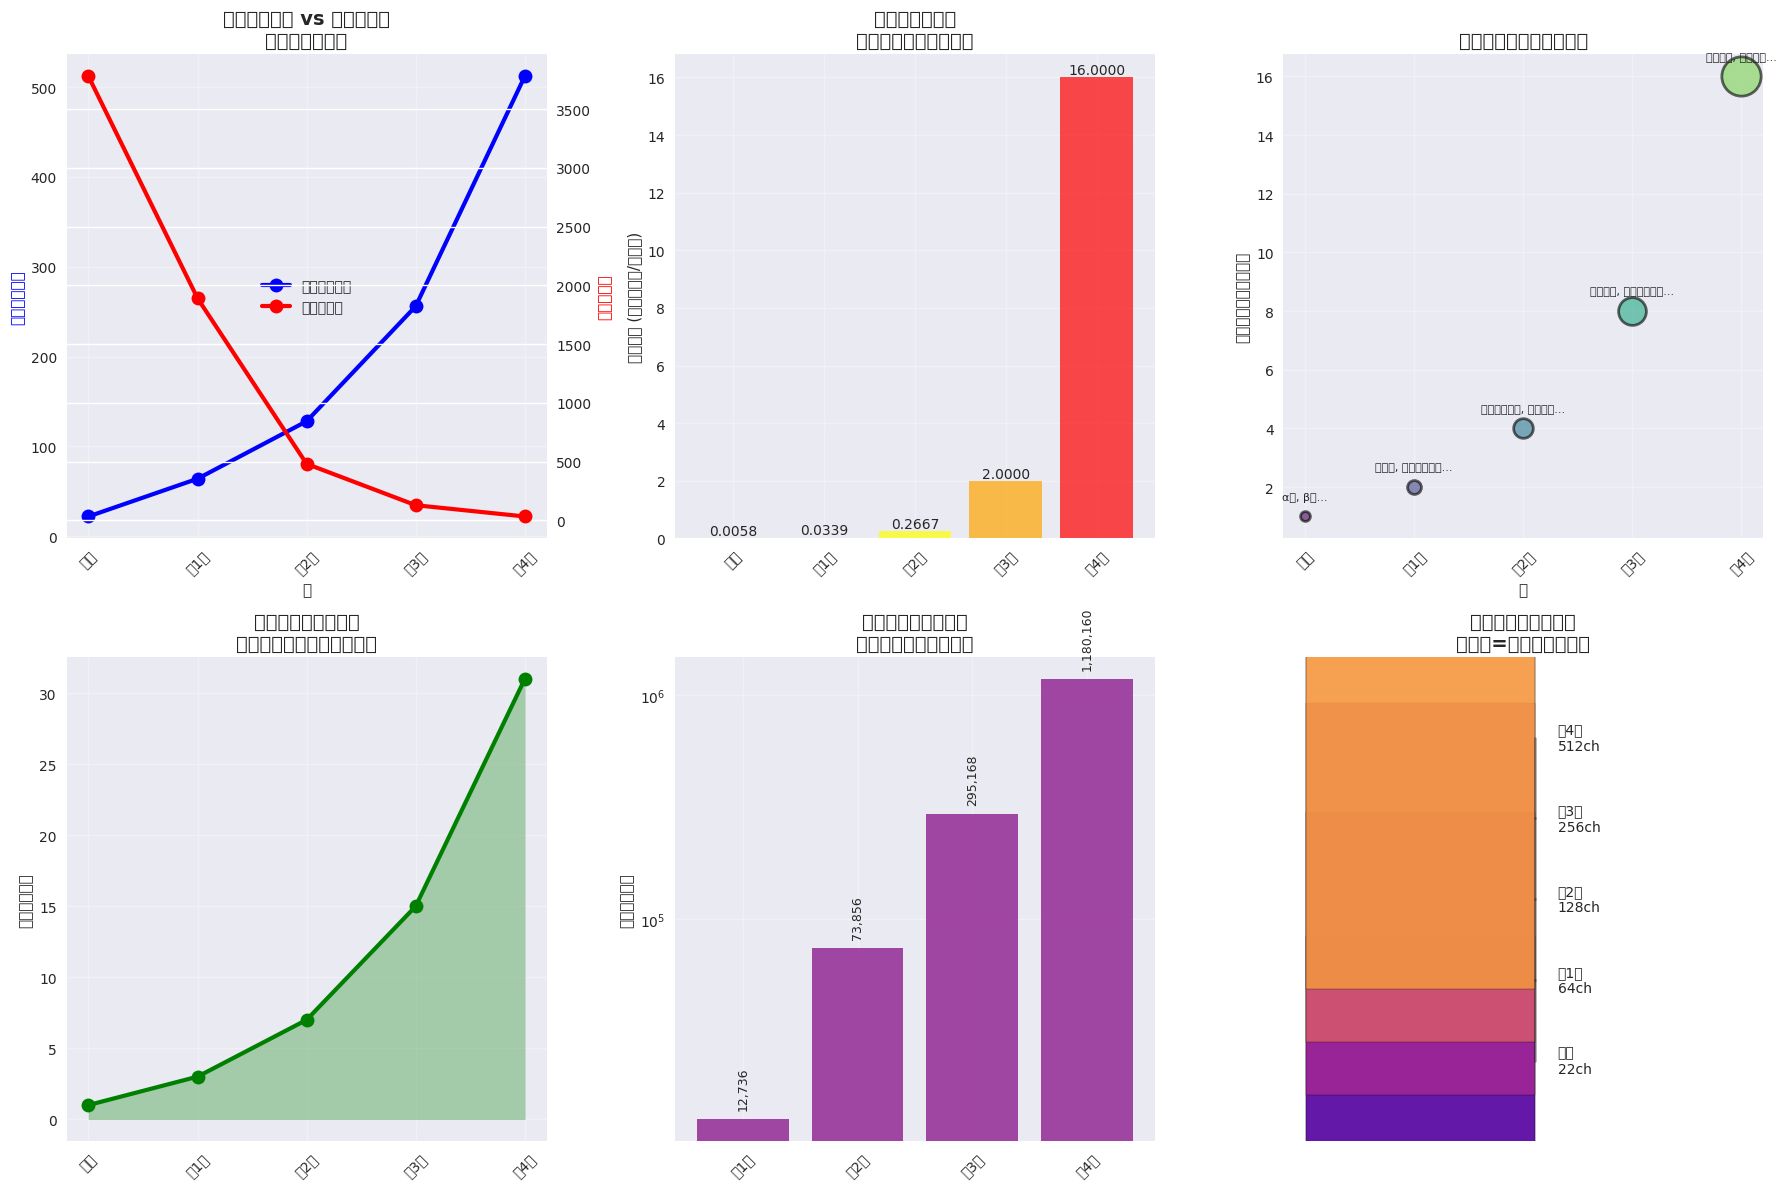

In [34]:
# チャンネル数増加の効果を視覚的に説明
def visualize_channel_progression_effects():
    """
    チャンネル数増加がもたらす効果を視覚的に説明
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # データの準備
    layers = ["入力", "第1層", "第2層", "第3層", "第4層"]
    channels = [22, 64, 128, 256, 512]
    spatial_sizes = [3780, 1890, 480, 128, 32]
    feature_complexity = [1, 2, 4, 8, 16]  # 相対的な特徴複雑度
    
    # 1. チャンネル数と空間サイズの関係
    ax1 = axes[0, 0]
    x_pos = np.arange(len(layers))
    
    ax1_twin = ax1.twinx()
    
    line1 = ax1.plot(x_pos, channels, 'bo-', linewidth=3, markersize=10, label='チャンネル数')
    line2 = ax1_twin.plot(x_pos, spatial_sizes, 'ro-', linewidth=3, markersize=10, label='空間サイズ')
    
    ax1.set_xlabel('層')
    ax1.set_ylabel('チャンネル数', color='blue')
    ax1_twin.set_ylabel('空間サイズ', color='red')
    ax1.set_title('チャンネル数 vs 空間サイズ\n（逆相関関係）', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(layers, rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 凡例を統合
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center')
    
    # 2. 情報密度の変化
    ax2 = axes[0, 1]
    info_density = [c/s for c, s in zip(channels, spatial_sizes)]
    
    bars = ax2.bar(layers, info_density, color=['skyblue', 'lightgreen', 'yellow', 'orange', 'red'], alpha=0.7)
    ax2.set_ylabel('情報密度 (チャンネル/空間点)')
    ax2.set_title('情報密度の増加\n（効率的な特徴表現）', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    # 各バーに値を表示
    for bar, density in zip(bars, info_density):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{density:.4f}', ha='center', va='bottom', fontsize=10)
    
    # 3. 特徴複雑度の増加
    ax3 = axes[0, 2]
    
    # 各層での特徴タイプを模擬的に表現
    feature_types = [
        ["α波", "β波", "θ波", "γ波"],
        ["エッジ", "局所パターン", "時間変化", "周波数変調"],
        ["複合パターン", "空間結合", "時間-周波数", "相互作用"],
        ["運動準備", "想像パターン", "注意状態", "認知負荷"],
        ["意図認識", "状態分類", "個人特性", "複雑判断"]
    ]
    
    # 特徴複雑度を円の大きさで表現
    for i, (layer, complexity) in enumerate(zip(layers, feature_complexity)):
        circle_size = complexity * 50
        ax3.scatter(i, complexity, s=circle_size, alpha=0.6, 
                   c=plt.cm.viridis(i/len(layers)), edgecolors='black', linewidth=2)
        
        # 特徴例をテキストで表示
        if i < len(feature_types):
            examples = ", ".join(feature_types[i][:2]) + "..."
            ax3.text(i, complexity + 0.5, examples, ha='center', va='bottom', 
                    fontsize=8, wrap=True)
    
    ax3.set_xlabel('層')
    ax3.set_ylabel('特徴複雑度（相対値）')
    ax3.set_title('特徴複雑度の階層的増加', fontsize=14, fontweight='bold')
    ax3.set_xticks(range(len(layers)))
    ax3.set_xticklabels(layers, rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. 受容野サイズの拡大
    ax4 = axes[1, 0]
    
    # 各層での受容野サイズ（理論値）
    receptive_field_sizes = [1, 3, 7, 15, 31]  # 簡易計算
    
    ax4.plot(layers, receptive_field_sizes, 'go-', linewidth=3, markersize=10)
    ax4.fill_between(layers, 0, receptive_field_sizes, alpha=0.3, color='green')
    ax4.set_ylabel('受容野サイズ')
    ax4.set_title('受容野の指数的拡大\n（より広範囲の情報統合）', fontsize=14, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    # 5. 学習パラメータ数の変化
    ax5 = axes[1, 1]
    
    # 各層でのパラメータ数（概算）
    kernel_size = 3
    param_counts = []
    for i in range(len(channels)-1):
        # Conv2d parameters: in_channels * out_channels * kernel_h * kernel_w + bias
        if i == 0:
            params = 22 * channels[i+1] * kernel_size * kernel_size + channels[i+1]
        else:
            params = channels[i] * channels[i+1] * kernel_size * kernel_size + channels[i+1]
        param_counts.append(params)
    
    bars = ax5.bar(layers[1:], param_counts, color='purple', alpha=0.7)
    ax5.set_ylabel('パラメータ数')
    ax5.set_title('各層のパラメータ数\n（学習する重みの数）', fontsize=14, fontweight='bold')
    ax5.tick_params(axis='x', rotation=45)
    ax5.set_yscale('log')
    ax5.grid(True, alpha=0.3)
    
    # パラメータ数を表示
    for bar, count in zip(bars, param_counts):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{count:,}', ha='center', va='bottom', fontsize=9, rotation=90)
    
    # 6. 全体の情報フロー
    ax6 = axes[1, 2]
    
    # サンキー図風の情報フロー表現
    y_positions = np.arange(len(layers))
    widths = [np.log(c) for c in channels]  # ログスケールで幅を決定
    
    for i, (y, width, layer) in enumerate(zip(y_positions, widths, layers)):
        color = plt.cm.plasma(i / len(layers))
        rect = plt.Rectangle((0, y-width/2), 1, width, facecolor=color, alpha=0.7, edgecolor='black')
        ax6.add_patch(rect)
        
        # 層名とチャンネル数を表示
        ax6.text(1.1, y, f'{layer}\n{channels[i]}ch', va='center', fontsize=10)
        
        # 次の層への流れを示す
        if i < len(layers) - 1:
            next_width = widths[i+1]
            # 流れを示す線
            ax6.plot([1, 1], [y, y_positions[i+1]], 'k-', alpha=0.3, linewidth=2)
    
    ax6.set_xlim(-0.1, 2)
    ax6.set_ylim(-1, len(layers))
    ax6.set_title('情報フローの可視化\n（太さ=チャンネル数）', fontsize=14, fontweight='bold')
    ax6.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'channels': channels,
        'spatial_sizes': spatial_sizes,
        'info_density': info_density,
        'param_counts': param_counts
    }

# 実行
print("\n=== チャンネル数増加の効果の可視化 ===\n")
results = visualize_channel_progression_effects()

In [35]:
# 実際のEEGデータでの具体例
def demonstrate_eeg_feature_hierarchy():
    """
    EEGデータにおける階層的特徴学習の具体例
    """
    print("=== EEGデータでの階層的特徴学習の実例 ===\n")
    
    # 各層で学習される特徴の例
    layer_features = {
        "入力層 (22チャンネル)": {
            "特徴": [
                "C3電極の生信号", "C4電極の生信号", "Cz電極の生信号",
                "各電極でのα波成分", "各電極でのβ波成分"
            ],
            "意味": "物理的な電極位置での電位変化",
            "例": "C3: -2.3μV, C4: +1.8μV, Cz: +0.5μV"
        },
        
        "第1層 (64チャンネル)": {
            "特徴": [
                "局所的な電位勾配", "隣接電極間の位相差",
                "短時間フーリエ変換の局所成分", "時間微分パターン"
            ],
            "意味": "基本的な時間-空間-周波数パターン",
            "例": "C3-C4間の電位差、10Hz成分の時間変化"
        },
        
        "第2層 (128チャンネル)": {
            "特徴": [
                "運動野での同期/脱同期パターン", "ERD/ERS検出器",
                "複数電極での協調パターン", "特定周波数帯での空間フィルタ"
            ],
            "意味": "生理学的に意味のある脳活動パターン",
            "例": "左手運動想像時のC4でのβ波ERD"
        },
        
        "第3層 (256チャンネル)": {
            "特徴": [
                "運動想像タイプ分類器", "注意状態検出器",
                "個人固有の脳活動パターン", "タスク依存の神経マーカー"
            ],
            "意味": "認知状態や意図の識別",
            "例": "左手 vs 右手運動想像の判別特徴"
        },
        
        "第4層 (512チャンネル)": {
            "特徴": [
                "高次認知機能パターン", "個人認証特徴",
                "疲労度・集中度指標", "学習効果パターン"
            ],
            "意味": "複雑な認知・行動状態の抽象的表現",
            "例": "この人の今日の集中度レベル"
        }
    }
    
    # 各層の詳細を表示
    for layer_name, info in layer_features.items():
        print(f"🧠 **{layer_name}**")
        print(f"   意味: {info['意味']}")
        print(f"   学習する特徴:")
        for feature in info['特徴']:
            print(f"     • {feature}")
        print(f"   具体例: {info['例']}")
        print()
    
    print("\n🔬 **重要な観察**\n")
    print("1. **抽象化の段階**:")
    print("   物理信号 → 基本パターン → 生理パターン → 認知パターン → 行動パターン\n")
    
    print("2. **情報の統合**:")
    print("   各層でより多くの入力情報を統合して、より高次の概念を形成\n")
    
    print("3. **特徴の特化**:")
    print("   チャンネル数が多いほど、より特化した特徴検出器を学習可能\n")
    
    print("4. **ロバスト性の向上**:")
    print("   複数の特徴チャンネルで同じ概念を異なる角度から捉える\n")
    
    # チャンネル数と学習可能な特徴パターン数の関係
    print("📊 **チャンネル数と表現能力の関係**\n")
    
    layers_info = [
        (22, "22個の基本特徴", "物理的制約"),
        (64, "約4,000個の組み合わせ", "2次特徴"),
        (128, "約16,000個の組み合わせ", "3次特徴"),
        (256, "約65,000個の組み合わせ", "4次特徴"),
        (512, "約260,000個の組み合わせ", "5次特徴")
    ]
    
    for channels, combinations, level in layers_info:
        print(f"   {channels:3d}チャンネル: {combinations:<25} ({level})")
    
    print("\n💡 **なぜ段階的に増やすのか - まとめ**\n")
    reasons = [
        "🎯 **効率的な学習**: 一度に複雑な特徴を学習するより段階的が効果的",
        "🛡️ **勾配消失対策**: 層が深くても勾配が流れやすい構造",
        "🔧 **計算効率**: 必要な箇所でのみチャンネル数を増加",
        "🧪 **表現力の調整**: 各層で適切な表現力を確保",
        "📈 **安定した学習**: 急激な変化を避けて安定した最適化"
    ]
    
    for reason in reasons:
        print(f"   {reason}")

# 実行
demonstrate_eeg_feature_hierarchy()

=== EEGデータでの階層的特徴学習の実例 ===

🧠 **入力層 (22チャンネル)**
   意味: 物理的な電極位置での電位変化
   学習する特徴:
     • C3電極の生信号
     • C4電極の生信号
     • Cz電極の生信号
     • 各電極でのα波成分
     • 各電極でのβ波成分
   具体例: C3: -2.3μV, C4: +1.8μV, Cz: +0.5μV

🧠 **第1層 (64チャンネル)**
   意味: 基本的な時間-空間-周波数パターン
   学習する特徴:
     • 局所的な電位勾配
     • 隣接電極間の位相差
     • 短時間フーリエ変換の局所成分
     • 時間微分パターン
   具体例: C3-C4間の電位差、10Hz成分の時間変化

🧠 **第2層 (128チャンネル)**
   意味: 生理学的に意味のある脳活動パターン
   学習する特徴:
     • 運動野での同期/脱同期パターン
     • ERD/ERS検出器
     • 複数電極での協調パターン
     • 特定周波数帯での空間フィルタ
   具体例: 左手運動想像時のC4でのβ波ERD

🧠 **第3層 (256チャンネル)**
   意味: 認知状態や意図の識別
   学習する特徴:
     • 運動想像タイプ分類器
     • 注意状態検出器
     • 個人固有の脳活動パターン
     • タスク依存の神経マーカー
   具体例: 左手 vs 右手運動想像の判別特徴

🧠 **第4層 (512チャンネル)**
   意味: 複雑な認知・行動状態の抽象的表現
   学習する特徴:
     • 高次認知機能パターン
     • 個人認証特徴
     • 疲労度・集中度指標
     • 学習効果パターン
   具体例: この人の今日の集中度レベル


🔬 **重要な観察**

1. **抽象化の段階**:
   物理信号 → 基本パターン → 生理パターン → 認知パターン → 行動パターン

2. **情報の統合**:
   各層でより多くの入力情報を統合して、より高次の概念を形成

3. **特徴の特化**:
   チャンネル数が多いほど、より特化した特徴検出器を学習可能

4. **

=== チャンネル数増加戦略の比較 ===

📊 **各戦略の詳細分析**

🔸 **段階的増加 (推奨)**
   チャンネル構成: 22 → 64 → 128 → 256 → 512
   説明: 段階的にチャンネル数を増加
   概算パラメータ数: 1,560,960
   メリット:
     ✅ 安定した学習
     ✅ 効率的な特徴抽出
     ✅ 勾配流動性良好
   デメリット:
     ❌ パラメータ数がやや多い

🔸 **一定チャンネル数**
   チャンネル構成: 22 → 22 → 22 → 22 → 22
   説明: 全層で同じチャンネル数
   概算パラメータ数: 17,424
   メリット:
     ✅ パラメータ数少ない
     ✅ シンプル
   デメリット:
     ❌ 表現力不足
     ❌ 特徴抽出効率悪い
     ❌ 情報ボトルネック

🔸 **急激な増加**
   チャンネル構成: 22 → 512 → 512 → 512 → 512
   説明: 最初から大量チャンネル
   概算パラメータ数: 7,179,264
   メリット:
     ✅ 高い表現力
   デメリット:
     ❌ 過学習しやすい
     ❌ 計算コスト高
     ❌ 学習不安定

🔸 **逆段階減少**
   チャンネル構成: 22 → 16 → 12 → 8 → 4
   説明: チャンネル数を減少
   概算パラメータ数: 6,048
   メリット:
     ✅ パラメータ数最少
   デメリット:
     ❌ 表現力大幅低下
     ❌ 情報損失大
     ❌ 性能低下

🔸 **ピラミッド型**
   チャンネル構成: 22 → 128 → 256 → 128 → 64
   説明: 中間で最大、両端で減少
   概算パラメータ数: 688,896
   メリット:
     ✅ 中間層で高表現力
   デメリット:
     ❌ 最終層で情報圧縮困難



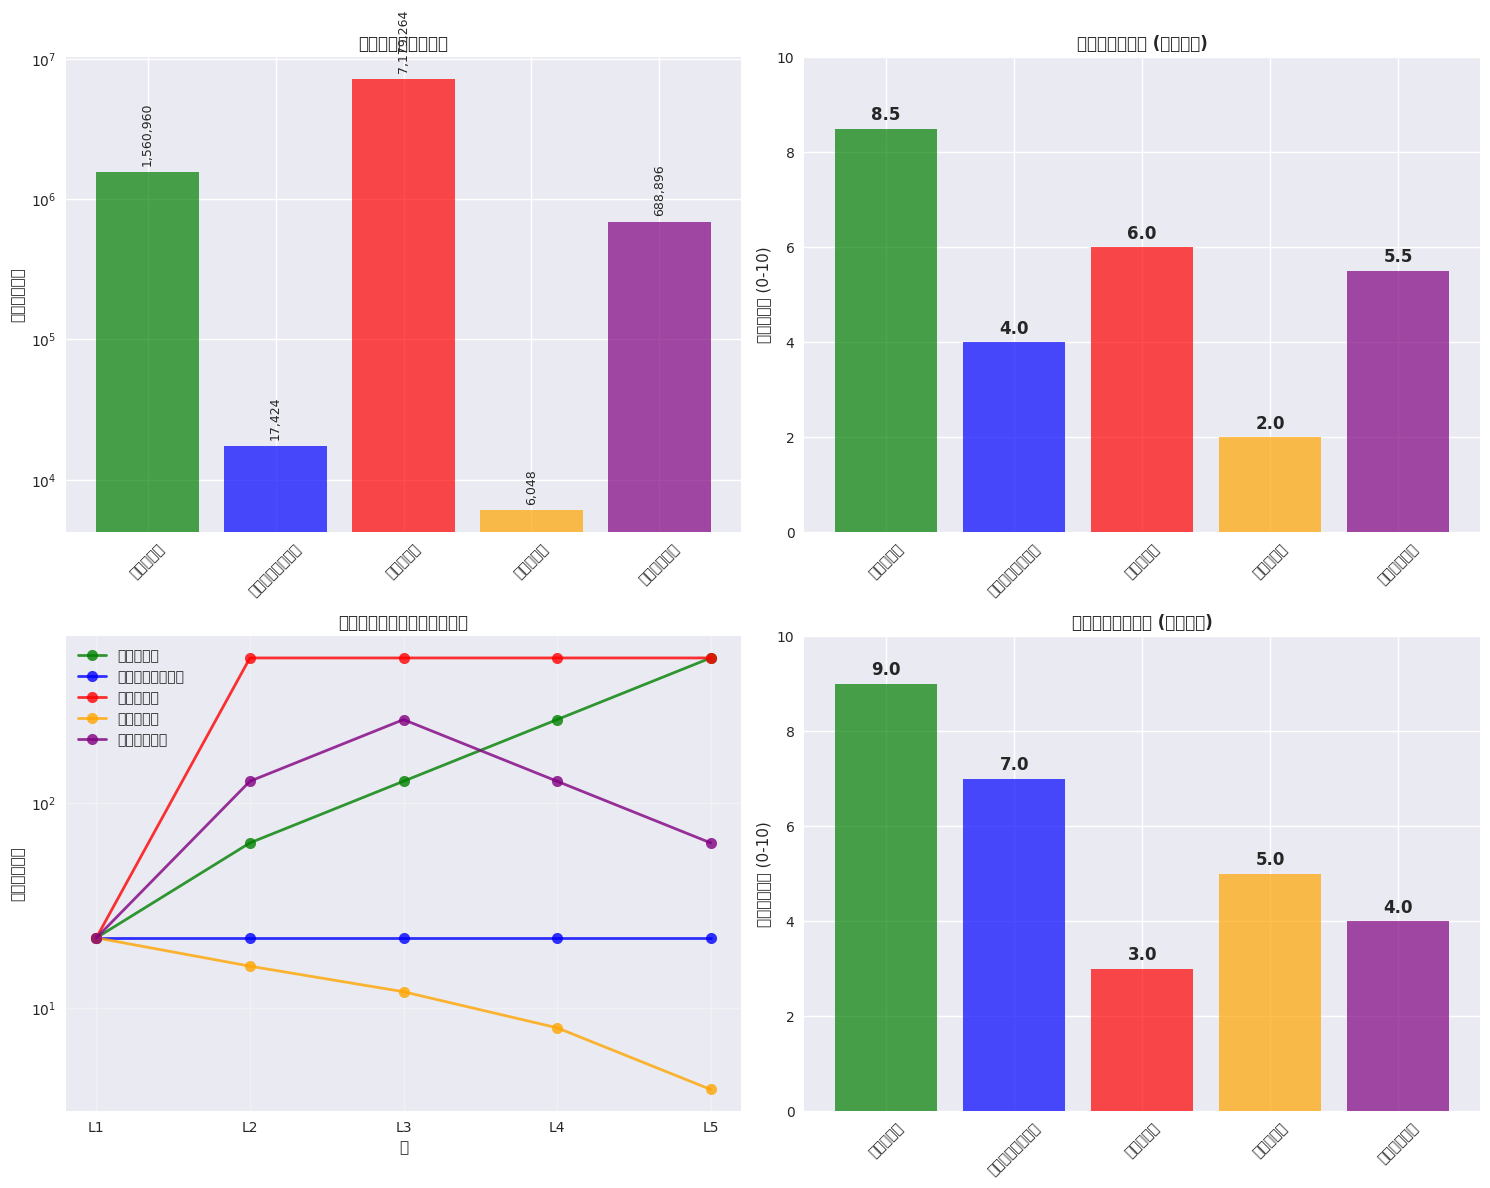


🏆 **結論: なぜ段階的増加が最適か**

   📈 **バランスの取れた性能**: パラメータ数と性能のトレードオフが最適
   🎯 **安定した学習**: 勾配の流れが良く、局所最適解に陥りにくい
   🧠 **生物学的妥当性**: 人間の視覚システムと類似の階層構造
   💻 **計算効率**: 必要な箇所でのみリソースを集中
   🔧 **実装の柔軟性**: 層ごとに調整可能で拡張性が高い
   📊 **実績**: 多くの成功事例で証明された効果的な手法


In [36]:
# チャンネル数設計の代替案との比較
def compare_channel_progression_strategies():
    """
    異なるチャンネル数増加戦略の比較
    """
    print("=== チャンネル数増加戦略の比較 ===\n")
    
    # 異なる戦略を定義
    strategies = {
        "段階的増加 (推奨)": {
            "channels": [22, 64, 128, 256, 512],
            "description": "段階的にチャンネル数を増加",
            "pros": ["安定した学習", "効率的な特徴抽出", "勾配流動性良好"],
            "cons": ["パラメータ数がやや多い"]
        },
        
        "一定チャンネル数": {
            "channels": [22, 22, 22, 22, 22],
            "description": "全層で同じチャンネル数",
            "pros": ["パラメータ数少ない", "シンプル"],
            "cons": ["表現力不足", "特徴抽出効率悪い", "情報ボトルネック"]
        },
        
        "急激な増加": {
            "channels": [22, 512, 512, 512, 512],
            "description": "最初から大量チャンネル",
            "pros": ["高い表現力"],
            "cons": ["過学習しやすい", "計算コスト高", "学習不安定"]
        },
        
        "逆段階減少": {
            "channels": [22, 16, 12, 8, 4],
            "description": "チャンネル数を減少",
            "pros": ["パラメータ数最少"],
            "cons": ["表現力大幅低下", "情報損失大", "性能低下"]
        },
        
        "ピラミッド型": {
            "channels": [22, 128, 256, 128, 64],
            "description": "中間で最大、両端で減少",
            "pros": ["中間層で高表現力"],
            "cons": ["最終層で情報圧縮困難"]
        }
    }
    
    # 各戦略の分析
    print("📊 **各戦略の詳細分析**\n")
    
    for strategy_name, info in strategies.items():
        print(f"🔸 **{strategy_name}**")
        print(f"   チャンネル構成: {' → '.join(map(str, info['channels']))}")
        print(f"   説明: {info['description']}")
        
        # パラメータ数を概算
        total_params = 0
        for i in range(len(info['channels'])-1):
            params = info['channels'][i] * info['channels'][i+1] * 9  # 3x3カーネル
            total_params += params
        
        print(f"   概算パラメータ数: {total_params:,}")
        
        print("   メリット:")
        for pro in info['pros']:
            print(f"     ✅ {pro}")
        
        print("   デメリット:")
        for con in info['cons']:
            print(f"     ❌ {con}")
        print()
    
    # 性能予測の可視化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    strategy_names = list(strategies.keys())
    colors = ['green', 'blue', 'red', 'orange', 'purple']
    
    # 1. パラメータ数の比較
    ax1 = axes[0, 0]
    param_counts = []
    for strategy in strategies.values():
        total_params = sum(strategy['channels'][i] * strategy['channels'][i+1] * 9 
                          for i in range(len(strategy['channels'])-1))
        param_counts.append(total_params)
    
    bars = ax1.bar(range(len(strategy_names)), param_counts, color=colors, alpha=0.7)
    ax1.set_title('パラメータ数の比較', fontweight='bold')
    ax1.set_ylabel('パラメータ数')
    ax1.set_xticks(range(len(strategy_names)))
    ax1.set_xticklabels([name.split()[0] for name in strategy_names], rotation=45)
    ax1.set_yscale('log')
    
    # 各バーに値を表示
    for bar, count in zip(bars, param_counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                f'{count:,}', ha='center', va='bottom', fontsize=9, rotation=90)
    
    # 2. 予想性能（主観的評価）
    ax2 = axes[0, 1]
    # 主観的な性能評価（0-10スケール）
    performance_scores = [8.5, 4.0, 6.0, 2.0, 5.5]  # 段階的増加が最高
    
    bars = ax2.bar(range(len(strategy_names)), performance_scores, color=colors, alpha=0.7)
    ax2.set_title('予想性能スコア (主観評価)', fontweight='bold')
    ax2.set_ylabel('性能スコア (0-10)')
    ax2.set_xticks(range(len(strategy_names)))
    ax2.set_xticklabels([name.split()[0] for name in strategy_names], rotation=45)
    ax2.set_ylim(0, 10)
    
    # スコアを表示
    for bar, score in zip(bars, performance_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{score}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # 3. チャンネル数の遷移
    ax3 = axes[1, 0]
    layers = ['L1', 'L2', 'L3', 'L4', 'L5']
    
    for i, (strategy_name, info) in enumerate(strategies.items()):
        ax3.plot(layers, info['channels'], 'o-', linewidth=2, markersize=8, 
                color=colors[i], label=strategy_name.split()[0], alpha=0.8)
    
    ax3.set_title('チャンネル数の遷移パターン', fontweight='bold')
    ax3.set_ylabel('チャンネル数')
    ax3.set_xlabel('層')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_yscale('log')
    
    # 4. 学習安定性の予測
    ax4 = axes[1, 1]
    # 学習安定性の主観評価
    stability_scores = [9.0, 7.0, 3.0, 5.0, 4.0]
    
    bars = ax4.bar(range(len(strategy_names)), stability_scores, color=colors, alpha=0.7)
    ax4.set_title('学習安定性スコア (主観評価)', fontweight='bold')
    ax4.set_ylabel('安定性スコア (0-10)')
    ax4.set_xticks(range(len(strategy_names)))
    ax4.set_xticklabels([name.split()[0] for name in strategy_names], rotation=45)
    ax4.set_ylim(0, 10)
    
    # スコアを表示
    for bar, score in zip(bars, stability_scores):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{score}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🏆 **結論: なぜ段階的増加が最適か**\n")
    
    conclusions = [
        "📈 **バランスの取れた性能**: パラメータ数と性能のトレードオフが最適",
        "🎯 **安定した学習**: 勾配の流れが良く、局所最適解に陥りにくい",
        "🧠 **生物学的妥当性**: 人間の視覚システムと類似の階層構造",
        "💻 **計算効率**: 必要な箇所でのみリソースを集中",
        "🔧 **実装の柔軟性**: 層ごとに調整可能で拡張性が高い",
        "📊 **実績**: 多くの成功事例で証明された効果的な手法"
    ]
    
    for conclusion in conclusions:
        print(f"   {conclusion}")
    
    return strategies

# 実行
strategies_comparison = compare_channel_progression_strategies()

In [37]:
# チャンネル処理の可視化
import torch
import matplotlib.pyplot as plt
import numpy as np

# 小さなダミーデータでチャンネル処理を確認
def visualize_channel_processing():
    # ダミー入力データ (1サンプル, 22チャンネル, 63スケール, 60時間)
    dummy_input = torch.randn(1, 22, 63, 60)
    
    # 第1層の畳み込み層のみを取得
    first_conv = model.encoder[0]  # nn.Conv2d(22, 64, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1))
    
    # 畳み込み処理
    with torch.no_grad():
        output = first_conv(dummy_input)
    
    print(f"入力形状: {dummy_input.shape}")
    print(f"第1層出力形状: {output.shape}")
    print(f"チャンネル変換: {dummy_input.shape[1]} → {output.shape[1]}")
    
    # チャンネル処理の可視化
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # 入力データの可視化（最初の3チャンネル）
    for i in range(3):
        axes[0, i].imshow(dummy_input[0, i].numpy(), aspect='auto', cmap='viridis', origin='lower')
        axes[0, i].set_title(f'Input Channel {i+1}')
        axes[0, i].set_xlabel('Time')
        axes[0, i].set_ylabel('Scale')
    
    # 出力データの可視化（最初の3特徴チャンネル）
    for i in range(3):
        axes[1, i].imshow(output[0, i].numpy(), aspect='auto', cmap='plasma', origin='lower')
        axes[1, i].set_title(f'Output Feature {i+1}')
        axes[1, i].set_xlabel('Time')
        axes[1, i].set_ylabel('Scale')
    
    plt.tight_layout()
    plt.show()
    
    return dummy_input, output

# チャンネル重みの可視化
def visualize_channel_weights():
    # 第1層の重みを取得
    first_conv = model.encoder[0]
    weights = first_conv.weight.data  # shape: (64, 22, 3, 3)
    
    print(f"第1層重み形状: {weights.shape}")
    print(f"各出力チャンネルは {weights.shape[1]} 個の入力チャンネルから特徴を抽出")
    
    # 重みの統計
    channel_importance = weights.abs().mean(dim=(2, 3))  # (64, 22) - 各出力チャンネルに対する入力チャンネルの重要度
    
    # 入力チャンネルの重要度を可視化
    plt.figure(figsize=(12, 8))
    
    # 最初の8つの出力チャンネルについて入力チャンネル重要度を表示
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.bar(range(22), channel_importance[i].numpy())
        plt.title(f'Output Feature {i+1}\nInput Channel Importance')
        plt.xlabel('Input Channel')
        plt.ylabel('Weight Magnitude')
        plt.xticks(range(0, 22, 5))
    
    plt.tight_layout()
    plt.show()
    
    # 全体的なチャンネル重要度
    overall_importance = channel_importance.mean(dim=0)  # 全出力チャンネルでの平均
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(22), overall_importance.numpy())
    plt.title('Overall Input Channel Importance\n(Average across all output features)')
    plt.xlabel('EEG Channel Index')
    plt.ylabel('Average Weight Magnitude')
    plt.xticks(range(22))
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return channel_importance, overall_importance

# 実行
if 'model' in locals():
    print("=== チャンネル処理の可視化 ===")
    dummy_input, conv_output = visualize_channel_processing()
    
    print("\n=== チャンネル重みの分析 ===")
    channel_importance, overall_importance = visualize_channel_weights()
    
    # EEGチャンネル名（標準的な10-20システム）
    eeg_channels = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
                   'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    
    print("\n=== 最も重要なEEGチャンネル（Top 5） ===")
    top_channels = torch.argsort(overall_importance, descending=True)[:5]
    for i, ch_idx in enumerate(top_channels):
        ch_name = eeg_channels[ch_idx] if ch_idx < len(eeg_channels) else f"Ch{ch_idx}"
        importance = overall_importance[ch_idx].item()
        print(f"{i+1}. {ch_name} (Channel {ch_idx}): {importance:.4f}")
else:
    print("モデルが初期化されていません。前のセルを実行してください。")

=== チャンネル処理の可視化 ===


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
# チャンネル間相互作用の詳細分析
def analyze_channel_interactions():
    """
    畳み込み層でのチャンネル間相互作用を分析
    """
    if 'model' not in locals():
        print("モデルが初期化されていません")
        return
        
    first_conv = model.encoder[0]
    weights = first_conv.weight.data  # (64, 22, 3, 3)
    
    # 各出力特徴に対する入力チャンネルのペアワイズ相関
    channel_correlations = []
    
    for out_ch in range(min(8, weights.shape[0])):  # 最初の8つの出力チャンネル
        # 各出力チャンネルの重み (22, 3, 3)
        ch_weights = weights[out_ch]  # (22, 3, 3)
        
        # 3x3カーネルを平坦化 (22, 9)
        flattened_weights = ch_weights.view(22, -1)
        
        # チャンネル間の相関を計算
        correlation_matrix = torch.corrcoef(flattened_weights)
        channel_correlations.append(correlation_matrix)
    
    # 平均相関行列
    avg_correlation = torch.stack(channel_correlations).mean(dim=0)
    
    # 可視化
    plt.figure(figsize=(12, 10))
    
    # 相関行列のヒートマップ
    plt.subplot(2, 2, 1)
    plt.imshow(avg_correlation.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.title('Average Channel-Channel Correlation\nin Convolutional Weights')
    plt.xlabel('Channel Index')
    plt.ylabel('Channel Index')
    
    # 対角成分を除いた相関の分布
    plt.subplot(2, 2, 2)
    off_diagonal = avg_correlation[torch.triu(torch.ones_like(avg_correlation), diagonal=1) == 1]
    plt.hist(off_diagonal.numpy(), bins=30, alpha=0.7, edgecolor='black')
    plt.title('Distribution of Inter-Channel Correlations')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # 最も相関の高いチャンネルペア
    plt.subplot(2, 2, 3)
    # 上三角行列から最大値を見つける
    triu_mask = torch.triu(torch.ones_like(avg_correlation), diagonal=1)
    masked_corr = avg_correlation * triu_mask
    
    # 最も相関の高い10ペア
    flat_corr = masked_corr.flatten()
    top_indices = torch.argsort(flat_corr, descending=True)[:10]
    
    top_pairs = []
    for idx in top_indices:
        if flat_corr[idx] > 0:  # 正の相関のみ
            i, j = divmod(idx.item(), 22)
            correlation_val = avg_correlation[i, j].item()
            top_pairs.append((i, j, correlation_val))
    
    if top_pairs:
        channels_i, channels_j, correlations = zip(*top_pairs[:5])
        y_pos = np.arange(len(correlations))
        
        plt.barh(y_pos, correlations)
        plt.yticks(y_pos, [f'Ch{i}-Ch{j}' for i, j in zip(channels_i, channels_j)])
        plt.xlabel('Correlation Coefficient')
        plt.title('Top 5 Most Correlated Channel Pairs')
        plt.grid(True, alpha=0.3)
    
    # 空間的に隣接するチャンネルの相関（運動野周辺）
    plt.subplot(2, 2, 4)
    motor_channels = [6, 7, 8, 9, 10, 11, 12]  # C5, C3, C1, Cz, C2, C4, C6
    motor_corr = avg_correlation[motor_channels][:, motor_channels]
    
    plt.imshow(motor_corr.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.title('Motor Area Channels Correlation\n(C5, C3, C1, Cz, C2, C4, C6)')
    motor_labels = ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6']
    plt.xticks(range(len(motor_labels)), motor_labels)
    plt.yticks(range(len(motor_labels)), motor_labels)
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== チャンネル間相互作用の分析結果 ===")
    print(f"全チャンネル間の平均相関: {off_diagonal.mean().item():.4f} ± {off_diagonal.std().item():.4f}")
    print(f"最大チャンネル間相関: {off_diagonal.max().item():.4f}")
    print(f"最小チャンネル間相関: {off_diagonal.min().item():.4f}")
    
    if top_pairs:
        print("\n最も相関の高いチャンネルペア:")
        for i, (ch1, ch2, corr) in enumerate(top_pairs[:3]):
            ch1_name = eeg_channels[ch1] if ch1 < len(eeg_channels) else f"Ch{ch1}"
            ch2_name = eeg_channels[ch2] if ch2 < len(eeg_channels) else f"Ch{ch2}"
            print(f"{i+1}. {ch1_name} - {ch2_name}: {corr:.4f}")
    
    return avg_correlation, channel_correlations

# 実行
if 'model' in locals():
    print("=== チャンネル間相互作用の分析 ===")
    avg_corr, all_corrs = analyze_channel_interactions()
else:
    print("モデルが初期化されていません。前のセルを実行してください。")

モデルが初期化されていません。前のセルを実行してください。


In [ ]:
# 各層でのチャンネル特徴の変化を追跡
def track_channel_features_through_layers():
    """
    エンコーダの各層でチャンネル特徴がどのように変化するかを追跡
    """
    if 'model' not in locals():
        print("モデルが初期化されていません")
        return
    
    # 実際のデータサンプルを使用
    if 'X_test' in locals():
        sample_data = torch.FloatTensor(X_test[:1]).to(device)  # 1サンプル
    else:
        sample_data = torch.randn(1, 22, 63, 60).to(device)
    
    print(f"入力データ形状: {sample_data.shape}")
    
    # 各層の出力を取得
    layer_outputs = []
    x = sample_data
    
    # エンコーダの各層を個別に実行
    encoder_layers = [
        model.encoder[0],   # Conv2d + BatchNorm + ReLU + Dropout
        model.encoder[1],   # BatchNorm2d
        model.encoder[2],   # ReLU
        model.encoder[3],   # Dropout2d
        model.encoder[4],   # Conv2d
        model.encoder[5],   # BatchNorm2d
        model.encoder[6],   # ReLU
        model.encoder[7],   # Dropout2d
        model.encoder[8],   # Conv2d
        model.encoder[9],   # BatchNorm2d
        model.encoder[10],  # ReLU
        model.encoder[11],  # Dropout2d
        model.encoder[12],  # Conv2d
        model.encoder[13],  # BatchNorm2d
        model.encoder[14],  # ReLU
        model.encoder[15],  # Dropout2d
    ]
    
    # 畳み込み層のみを追跡
    conv_layer_indices = [0, 4, 8, 12]  # 各畳み込み層のインデックス
    conv_outputs = []
    
    with torch.no_grad():
        current_x = x
        layer_idx = 0
        
        for i, layer in enumerate(encoder_layers):
            current_x = layer(current_x)
            
            # 畳み込み層の出力を保存
            if i in conv_layer_indices:
                conv_outputs.append(current_x.clone())
                layer_idx += 1
                print(f"Layer {layer_idx} output shape: {current_x.shape}")
    
    # 各畳み込み層の出力を可視化
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    
    for layer_idx, output in enumerate(conv_outputs):
        # 各層から4つの特徴チャンネルを可視化
        for ch_idx in range(4):
            ax = axes[layer_idx, ch_idx]
            
            # 特徴マップを可視化
            feature_map = output[0, ch_idx].cpu().numpy()
            
            im = ax.imshow(feature_map, aspect='auto', cmap='viridis', origin='lower')
            ax.set_title(f'Layer {layer_idx+1}, Feature {ch_idx+1}\nShape: {feature_map.shape}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Scale')
            
            # カラーバーを追加
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # 各層での特徴の統計
    print("\n=== 各層での特徴統計 ===")
    for i, output in enumerate(conv_outputs):
        mean_activation = output.mean().item()
        std_activation = output.std().item()
        max_activation = output.max().item()
        min_activation = output.min().item()
        
        print(f"Layer {i+1}:")
        print(f"  平均活性化: {mean_activation:.4f}")
        print(f"  標準偏差: {std_activation:.4f}")
        print(f"  最大値: {max_activation:.4f}")
        print(f"  最小値: {min_activation:.4f}")
        print(f"  形状: {output.shape}")
        print()
    
    return conv_outputs

# チャンネル次元の圧縮効果を分析
def analyze_spatial_compression():
    """
    空間次元（スケール・時間）の圧縮がチャンネル特徴に与える影響を分析
    """
    if 'conv_outputs' not in locals():
        return
    
    print("=== 空間圧縮の効果 ===")
    
    # 各層での空間サイズとチャンネル数の変化
    spatial_sizes = []
    channel_counts = []
    
    for i, output in enumerate(conv_outputs):
        batch, channels, height, width = output.shape
        spatial_size = height * width
        spatial_sizes.append(spatial_size)
        channel_counts.append(channels)
        
        print(f"Layer {i+1}: {channels} channels, spatial size: {height}×{width} = {spatial_size}")
    
    # 圧縮率の計算
    initial_spatial = spatial_sizes[0]
    initial_channels = channel_counts[0]
    
    plt.figure(figsize=(12, 5))
    
    # 空間サイズの変化
    plt.subplot(1, 2, 1)
    compression_ratios = [size / initial_spatial for size in spatial_sizes]
    plt.plot(range(1, len(compression_ratios)+1), compression_ratios, 'bo-', linewidth=2, markersize=8)
    plt.title('Spatial Compression Through Layers')
    plt.xlabel('Layer')
    plt.ylabel('Spatial Size Ratio')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # チャンネル数の変化
    plt.subplot(1, 2, 2)
    channel_ratios = [ch / initial_channels for ch in channel_counts]
    plt.plot(range(1, len(channel_ratios)+1), channel_ratios, 'ro-', linewidth=2, markersize=8)
    plt.title('Channel Count Growth Through Layers')
    plt.xlabel('Layer')
    plt.ylabel('Channel Count Ratio')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n最終的な圧縮率: {compression_ratios[-1]:.4f} ({spatial_sizes[-1]}/{initial_spatial})")
    print(f"最終的なチャンネル増加率: {channel_ratios[-1]:.1f}x ({channel_counts[-1]}/{initial_channels})")

# 実行
if 'model' in locals():
    print("=== レイヤー間でのチャンネル特徴の追跡 ===")
    conv_outputs = track_channel_features_through_layers()
    
    print("\n=== 空間圧縮の分析 ===")
    analyze_spatial_compression()
else:
    print("モデルが初期化されていません。前のセルを実行してください。")

モデルが初期化されていません。前のセルを実行してください。


### チャンネル処理のまとめ

#### 1. **物理的チャンネルから特徴チャンネルへの変換**
- **入力**: 22個の物理的EEGセンサー位置
- **第1層出力**: 64個の学習された特徴チャンネル
- 各特徴チャンネルは、全入力チャンネルの重み付き組み合わせ

#### 2. **空間的特徴学習**
- 畳み込み演算により、異なるEEG電極間の空間的関係を学習
- 運動野（C3, C4, Cz周辺）などの機能的に関連する領域間の相互作用をキャプチャ
- ERD/ERS（Event-Related Desynchronization/Synchronization）パターンを効果的に抽出

#### 3. **階層的特徴抽出**
```
物理チャンネル → 低レベル特徴 → 中レベル特徴 → 高レベル特徴
      22      →      64      →     128     →     256
```

#### 4. **運動想像タスクへの適用**
- **左手運動想像**: 右運動野（C4周辺）のERDパターン
- **右手運動想像**: 左運動野（C3周辺）のERDパターン
- **足運動想像**: 中央運動野（Cz周辺）の特徴的活動
- **舌運動想像**: より広範囲な運動野活動パターン

#### 5. **時間-周波数ドメインでの処理**
- ウェーブレット変換により得られた時間-周波数表現
- 各チャンネルで異なる周波数帯域（α波、β波、μ波）の特徴を同時に学習
- 運動想像時の特徴的な周波数変化パターンを捉える

このアプローチにより、従来の手動特徴量設計では困難な、複雑な脳活動パターンの自動抽出が可能になります。

## モデルの初期化とトレーニング準備

In [38]:
# デバイスの設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# モデルパラメータ（4次元データに対応）
n_channels = X_train.shape[1]  # チャンネル数
n_scales = X_train.shape[2]    # スケール数（周波数軸）
n_times = X_train.shape[3]     # 時間軸
latent_dim = 128
batch_size = 16  # 2Dデータは大きいのでバッチサイズを小さく
learning_rate = 0.001
beta = 0.5  # β-VAEパラメータ

# モデルの初期化
model = Conv2DVAE(n_channels, n_scales, n_times, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# 学習率スケジューラ
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=20
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input shape: channels={n_channels}, scales={n_scales}, times={n_times}")
print(f"Latent dimension: {latent_dim}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Beta (KL weight): {beta}")

# モデル構造の確認
print("\nModel structure:")
print(model)

Using device: cuda
Encoder output shape: torch.Size([1, 512, 8, 10])
Encoded size: 40960
Model parameters: 18,906,399
Input shape: channels=31, scales=63, times=150
Latent dimension: 128
Batch size: 16
Learning rate: 0.001
Beta (KL weight): 0.5

Model structure:
Conv2DVAE(
  (encoder): Sequential(
    (0): Conv2d(31, 64, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.1, inplace=False)
    (12): Conv2d(256, 512, kern

In [39]:
# データローダーの作成
train_dataset = TensorDataset(torch.FloatTensor(X_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 6
Validation batches: 2
Test batches: 2


## モデルのトレーニング

In [40]:
def train_epoch(model, train_loader, optimizer, device, beta):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar, _ = model(data)
        loss, recon_loss, kld_loss = conv2d_vae_loss(recon_batch, data, mu, logvar, beta)
        
        loss.backward()
        # 勾配クリッピング
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kld_loss_total += kld_loss.item()
    
    return train_loss / len(train_loader.dataset), recon_loss_total / len(train_loader.dataset), kld_loss_total / len(train_loader.dataset)

def validate_epoch(model, val_loader, device, beta):
    model.eval()
    val_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    with torch.no_grad():
        for data, in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar, _ = model(data)
            loss, recon_loss, kld_loss = conv2d_vae_loss(recon_batch, data, mu, logvar, beta)
            
            val_loss += loss.item()
            recon_loss_total += recon_loss.item()
            kld_loss_total += kld_loss.item()
    
    return val_loss / len(val_loader.dataset), recon_loss_total / len(val_loader.dataset), kld_loss_total / len(val_loader.dataset)

In [41]:
# トレーニングループ
num_epochs = 500
train_losses = []
val_losses = []
train_recon_losses = []
val_recon_losses = []
train_kld_losses = []
val_kld_losses = []
learning_rates = []

best_val_loss = float('inf')
patience = 20
patience_counter = 0

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_recon, train_kld = train_epoch(model, train_loader, optimizer, device, beta)
    val_loss, val_recon, val_kld = validate_epoch(model, val_loader, device, beta)
    
    # スケジューラのステップ
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    val_recon_losses.append(val_recon)
    train_kld_losses.append(train_kld)
    val_kld_losses.append(val_kld)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Recon: {train_recon:.4f}, Train KLD: {train_kld:.4f}, '
              f'LR: {current_lr:.6f}')
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ベストモデルを保存
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': val_loss,
        }, 'best_2d_conv_vae_model.pth')
    # else:
    #     patience_counter += 1
    #     if patience_counter >= patience:
    #         print(f"Early stopping at epoch {epoch}")
    #         break

print("Training completed!")

Starting training...
Epoch   0: Train Loss: 1160470.2240, Val Loss: 262039.2188, Train Recon: 425694.2318, Train KLD: 1469551.9450, LR: 0.001000
Epoch   0: Train Loss: 1160470.2240, Val Loss: 262039.2188, Train Recon: 425694.2318, Train KLD: 1469551.9450, LR: 0.001000
Epoch  10: Train Loss: 2231223311.1458, Val Loss: 175189.6484, Train Recon: 361555.3828, Train KLD: 4461723397.1930, LR: 0.001000
Epoch  10: Train Loss: 2231223311.1458, Val Loss: 175189.6484, Train Recon: 361555.3828, Train KLD: 4461723397.1930, LR: 0.001000
Epoch  20: Train Loss: 344809.3281, Val Loss: 172165.5078, Train Recon: 338565.2344, Train KLD: 12488.1701, LR: 0.001000
Epoch  20: Train Loss: 344809.3281, Val Loss: 172165.5078, Train Recon: 338565.2344, Train KLD: 12488.1701, LR: 0.001000
Epoch  30: Train Loss: 6541238.3958, Val Loss: 170752.8203, Train Recon: 348155.6146, Train KLD: 12386165.7308, LR: 0.001000
Epoch  30: Train Loss: 6541238.3958, Val Loss: 170752.8203, Train Recon: 348155.6146, Train KLD: 1238616

## トレーニング結果の可視化

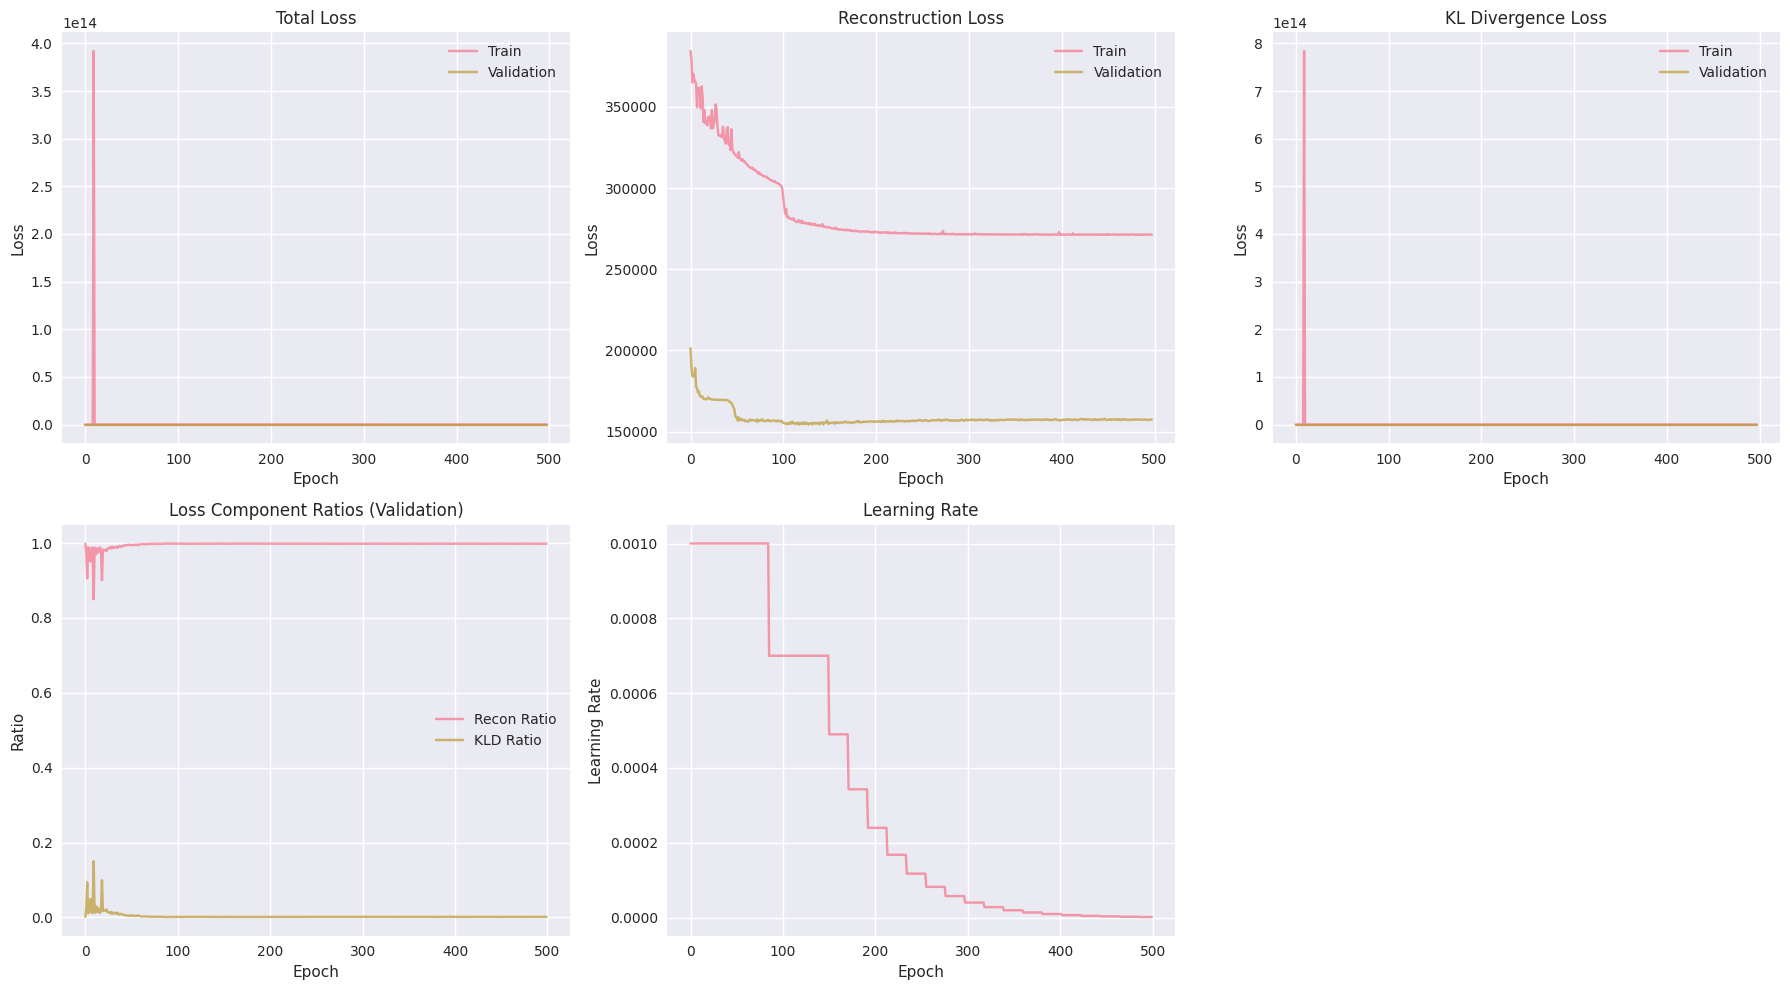

In [42]:
# ベストモデルをロード
checkpoint = torch.load('best_2d_conv_vae_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# 損失の推移をプロット
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 総損失
axes[0, 0].plot(train_losses[2:], label='Train', alpha=0.7)
axes[0, 0].plot(val_losses[2:], label='Validation', alpha=0.7)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 再構成損失
axes[0, 1].plot(train_recon_losses[2:], label='Train', alpha=0.7)
axes[0, 1].plot(val_recon_losses[2:], label='Validation', alpha=0.7)
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# KL損失
axes[0, 2].plot(train_kld_losses[2:], label='Train', alpha=0.7)
axes[0, 2].plot(val_kld_losses[2:], label='Validation', alpha=0.7)
axes[0, 2].set_title('KL Divergence Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 損失の比率
if len(val_recon_losses) > 0:
    recon_ratio = np.array(val_recon_losses) / (np.array(val_recon_losses) + np.array(val_kld_losses))
    kld_ratio = np.array(val_kld_losses) / (np.array(val_recon_losses) + np.array(val_kld_losses))
    axes[1, 0].plot(recon_ratio, label='Recon Ratio', alpha=0.7)
    axes[1, 0].plot(kld_ratio, label='KLD Ratio', alpha=0.7)
    axes[1, 0].set_title('Loss Component Ratios (Validation)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Ratio')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# 学習率の推移
axes[1, 1].plot(learning_rates, alpha=0.7)
axes[1, 1].set_title('Learning Rate')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].grid(True)

# 最後のプロットは空にする
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 再構成結果の可視化

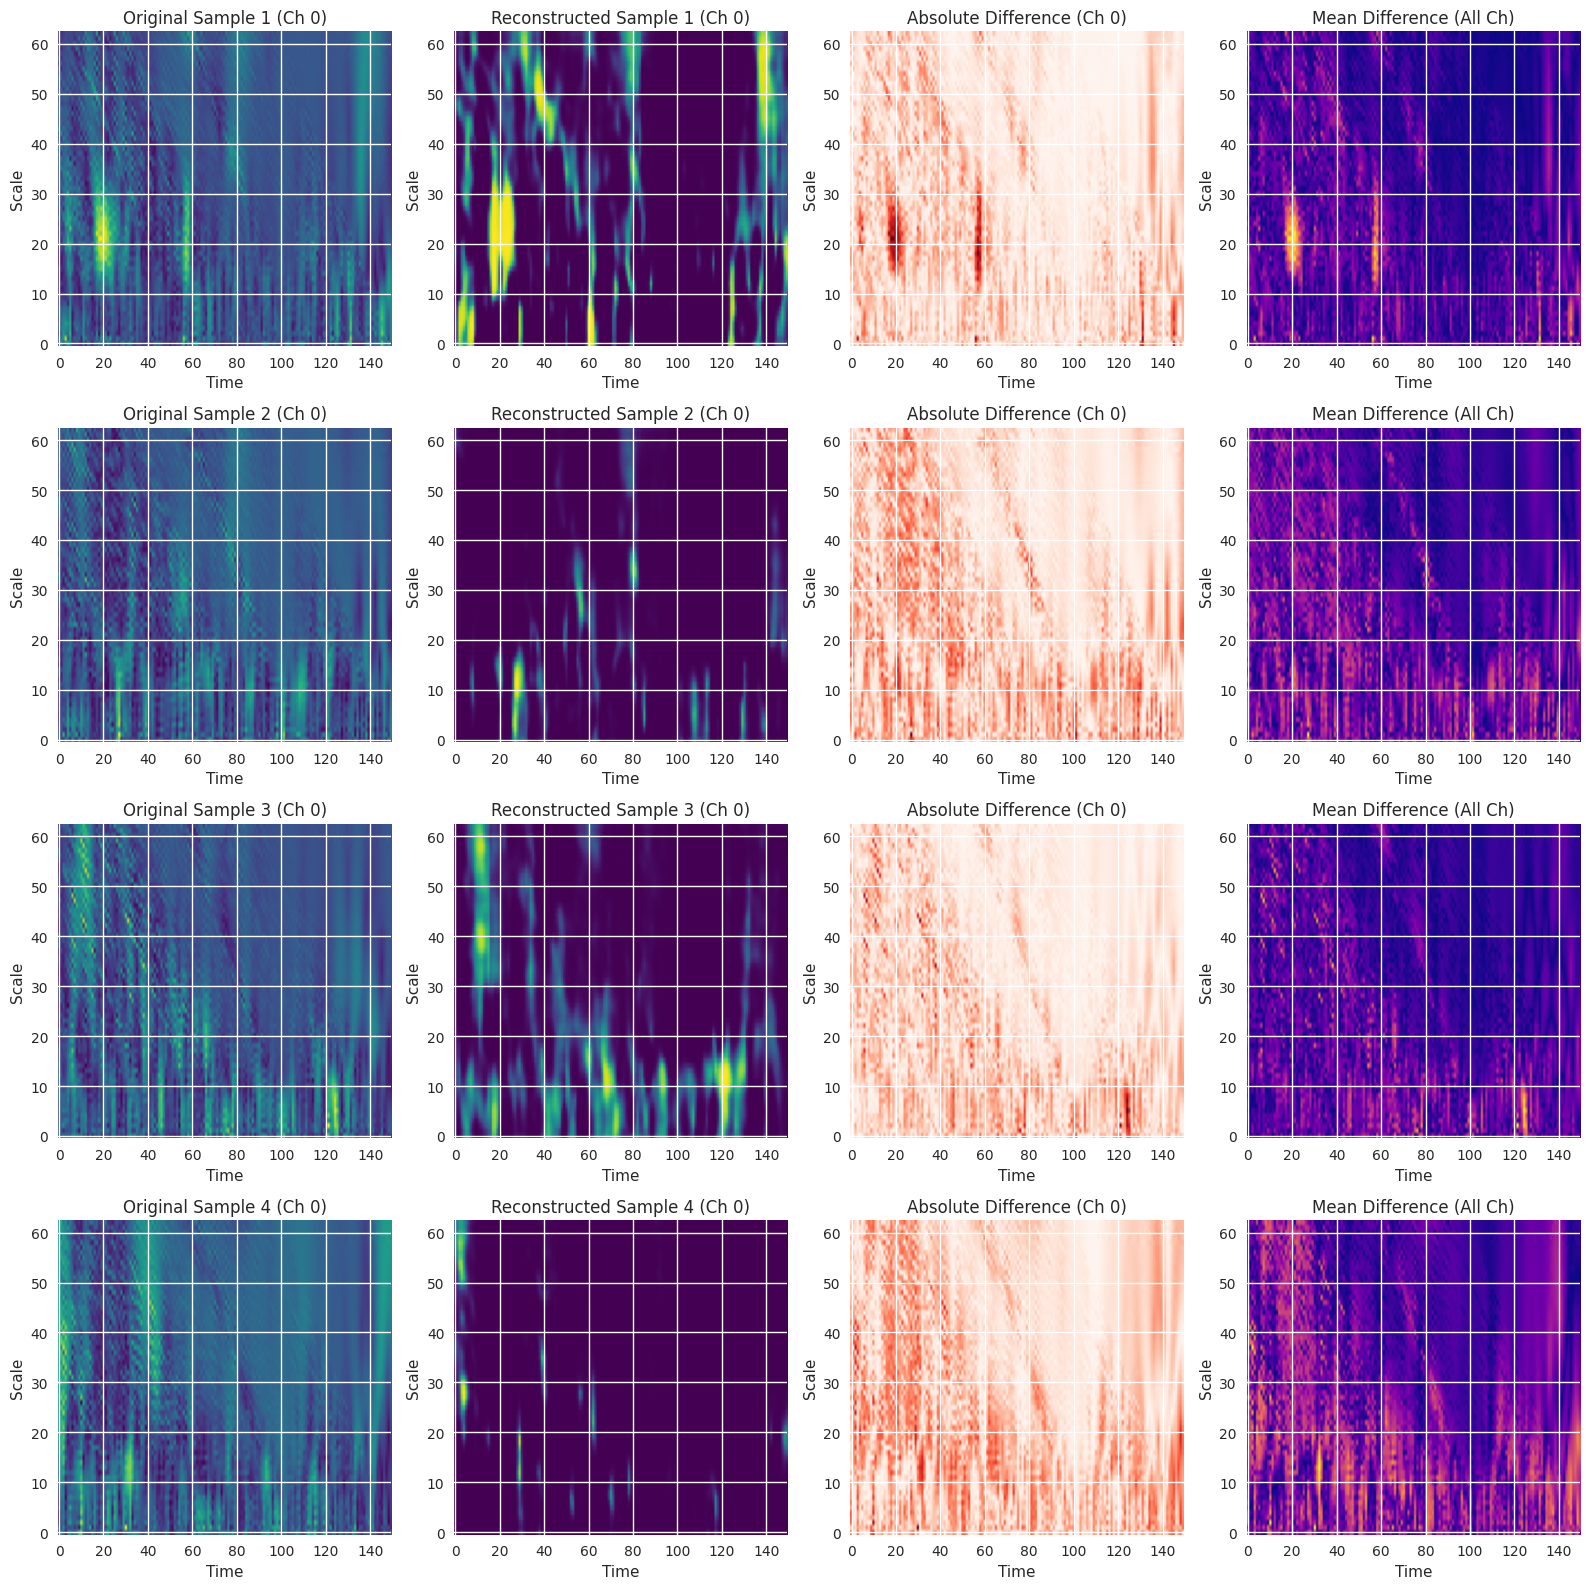

Reconstruction MSE per sample: [0.5736658  0.36680606 0.4850871  0.3949858 ]
Mean reconstruction MSE: 0.455136 ± 0.081189


In [43]:
# テストデータで再構成結果を確認
model.eval()
with torch.no_grad():
    # テストデータから数サンプルを取得
    test_samples = torch.FloatTensor(X_test[:4]).to(device)
    recon_samples, mu, logvar, z = model(test_samples)
    
    test_samples = test_samples.cpu().numpy()
    recon_samples = recon_samples.cpu().numpy()

# 再構成結果の可視化
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):
    # オリジナル（チャンネル0の時間-周波数表現）
    axes[i, 0].imshow(test_samples[i, 0], aspect='auto', cmap='viridis', origin='lower')
    axes[i, 0].set_title(f'Original Sample {i+1} (Ch 0)')
    axes[i, 0].set_xlabel('Time')
    axes[i, 0].set_ylabel('Scale')
    
    # 再構成（チャンネル0）
    axes[i, 1].imshow(recon_samples[i, 0], aspect='auto', cmap='viridis', origin='lower')
    axes[i, 1].set_title(f'Reconstructed Sample {i+1} (Ch 0)')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel('Scale')
    
    # 差分
    diff = np.abs(test_samples[i, 0] - recon_samples[i, 0])
    axes[i, 2].imshow(diff, aspect='auto', cmap='Reds', origin='lower')
    axes[i, 2].set_title(f'Absolute Difference (Ch 0)')
    axes[i, 2].set_xlabel('Time')
    axes[i, 2].set_ylabel('Scale')
    
    # 全チャンネル平均の比較
    orig_mean = test_samples[i].mean(axis=0)
    recon_mean = recon_samples[i].mean(axis=0)
    diff_mean = np.abs(orig_mean - recon_mean)
    axes[i, 3].imshow(diff_mean, aspect='auto', cmap='plasma', origin='lower')
    axes[i, 3].set_title(f'Mean Difference (All Ch)')
    axes[i, 3].set_xlabel('Time')
    axes[i, 3].set_ylabel('Scale')

plt.tight_layout()
plt.show()

# 再構成誤差の統計
mse_per_sample = np.mean((test_samples - recon_samples)**2, axis=(1, 2, 3))
print(f"Reconstruction MSE per sample: {mse_per_sample}")
print(f"Mean reconstruction MSE: {mse_per_sample.mean():.6f} ± {mse_per_sample.std():.6f}")

## 潜在特徴量の抽出と分析

In [44]:
# 全データに対して潜在特徴量を抽出
model.eval()
all_features = []
all_labels = []

with torch.no_grad():
    # 訓練データ
    for data, in train_loader:
        data = data.to(device)
        mu, logvar = model.encode(data)
        z = model.reparameterize(mu, logvar)
        all_features.append(z.cpu().numpy())
    all_labels.extend(y_train)
    
    # 検証データ
    for data, in val_loader:
        data = data.to(device)
        mu, logvar = model.encode(data)
        z = model.reparameterize(mu, logvar)
        all_features.append(z.cpu().numpy())
    all_labels.extend(y_val)
    
    # テストデータ
    for data, in test_loader:
        data = data.to(device)
        mu, logvar = model.encode(data)
        z = model.reparameterize(mu, logvar)
        all_features.append(z.cpu().numpy())
    all_labels.extend(y_test)

# 特徴量を結合
features = np.concatenate(all_features, axis=0)
labels_array = np.array(all_labels)

print(f"Extracted features shape: {features.shape}")
print(f"Labels shape: {labels_array.shape}")
print(f"Unique labels: {np.unique(labels_array)}")

Extracted features shape: (160, 128)
Labels shape: (160,)
Unique labels: [   1    2    3 9999]


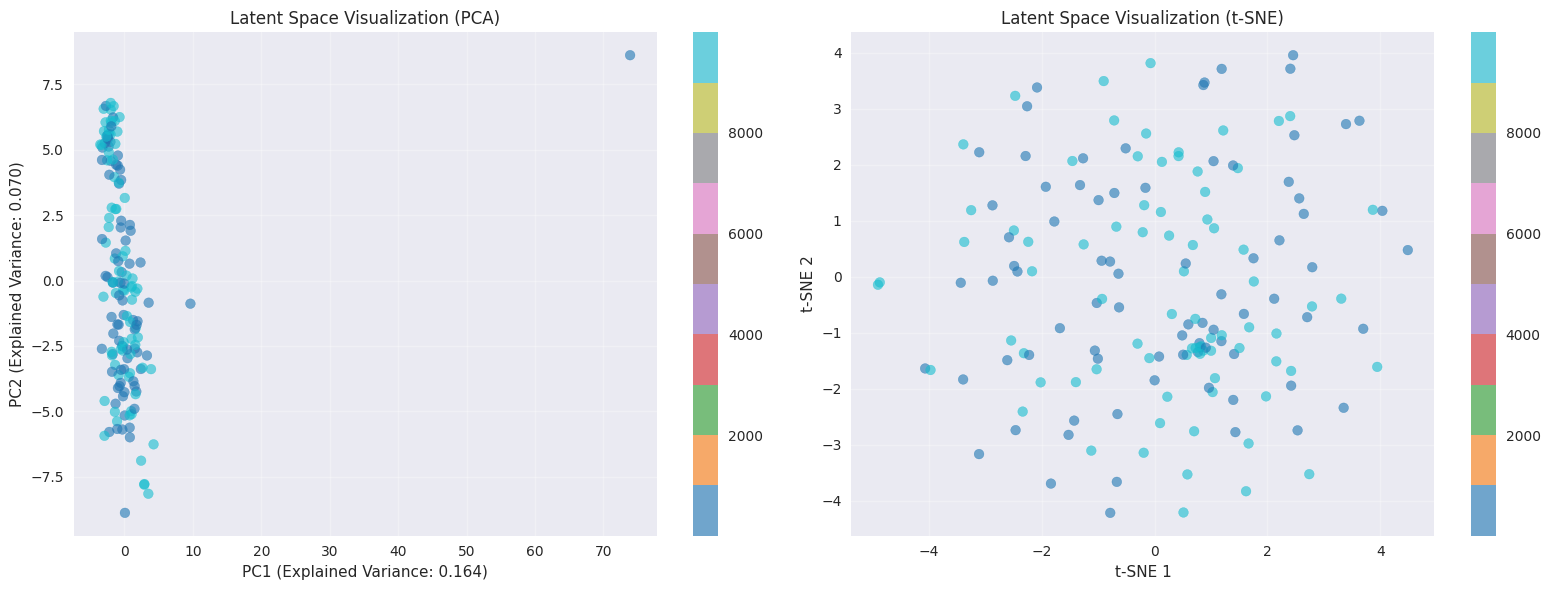

PCA explained variance ratio: [0.16385818 0.07049103]
Total explained variance: 0.234


In [45]:
# 潜在空間の可視化（PCA）
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCAで2次元に投影
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features)

# t-SNEで2次元に投影
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_tsne = tsne.fit_transform(features[:1000])  # メモリ節約のため最初の1000サンプル
labels_tsne = labels_array[:1000]

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA結果
scatter = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], c=labels_array, cmap='tab10', alpha=0.6)
axes[0].set_title('Latent Space Visualization (PCA)')
axes[0].set_xlabel(f'PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.3f})')
axes[0].set_ylabel(f'PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.3f})')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0])

# t-SNE結果
scatter2 = axes[1].scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels_tsne, cmap='tab10', alpha=0.6)
axes[1].set_title('Latent Space Visualization (t-SNE)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_[:2]}")
print(f"Total explained variance: {pca.explained_variance_ratio_[:2].sum():.3f}")

## 分類性能の評価

In [46]:
# VAE特徴量を使った分類評価
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

# 訓練/テスト分割
train_size = len(y_train)
val_size = len(y_val)

X_train_features = features[:train_size]
X_val_features = features[train_size:train_size+val_size]
X_test_features = features[train_size+val_size:]

# 複数の分類器で評価
classifiers = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}
for name, clf in classifiers.items():
    print(f"\n=== {name} ===")
    
    # 訓練
    clf.fit(X_train_features, y_train)
    
    # 予測
    y_pred = clf.predict(X_test_features)
    
    # 評価
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.4f}")
    
    # クロスバリデーション（訓練データで）
    cv_scores = cross_val_score(clf, X_train_features, y_train, cv=5)
    print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # 分類レポート
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    results[name] = {
        'test_accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }

# 結果の比較
print("\n=== Results Summary ===")
for name, result in results.items():
    print(f"{name}: Test Acc = {result['test_accuracy']:.4f}, CV Acc = {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")


=== SVM ===
Test Accuracy: 0.5000
CV Accuracy: 0.5005 ± 0.0325
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         5
        9999       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.12      0.25      0.17        32
weighted avg       0.25      0.50      0.33        32


=== Random Forest ===
Test Accuracy: 0.5000
CV Accuracy: 0.4689 ± 0.0346
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         5
        9999       0.50      1.00      0.67        16

    accuracy                           0.50        32
   macro avg       0.12      0.25      0.17        32
w

## 過学習問題の分析と対策

### 問題の確認
Training Lossは下がっているが、Validation Lossが上がっている現象は**過学習（Overfitting）**を示しています。

### 主な原因
1. **モデルの複雑性**: 4層の畳み込み+512チャンネル
2. **データ不足**: 1600エポックでは複雑なVAEには不十分
3. **正則化不足**: Dropout率、Weight decay、β値の設定
4. **学習率**: 初期学習率が高すぎる可能性

### 対策の実装

In [47]:
# 過学習対策を施した改善版VAEモデル
class ImprovedConv2DVAE(nn.Module):
    def __init__(self, n_channels=22, n_scales=63, n_times=60, latent_dim=64):
        super(ImprovedConv2DVAE, self).__init__()
        
        self.n_channels = n_channels
        self.n_scales = n_scales
        self.n_times = n_times
        self.latent_dim = latent_dim
        
        # より軽量なEncoder（チャンネル数を削減）
        self.encoder = nn.Sequential(
            # 入力: (batch, n_channels, n_scales, n_times)
            nn.Conv2d(n_channels, 32, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),  # Dropout率を増加
            
            # (batch, 32, n_scales, n_times//2)
            nn.Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            
            # (batch, 64, n_scales//2, n_times//4)
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.4),
            
            # Global Average Pooling for regularization
            nn.AdaptiveAvgPool2d((4, 4)),  # 固定サイズに圧縮
        )
        
        # エンコーダ出力サイズを計算
        self.encoded_size = 128 * 4 * 4  # 128チャンネル × 4 × 4
        
        # 潜在変数の平均と分散
        self.fc_mu = nn.Sequential(
            nn.Linear(self.encoded_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, latent_dim)
        )
        
        self.fc_logvar = nn.Sequential(
            nn.Linear(self.encoded_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, latent_dim)
        )
        
        # Decoder
        self.fc_decode = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, self.encoded_size)
        )
        
        # より軽量なDecoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.4),
            
            nn.ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            
            nn.ConvTranspose2d(32, n_channels, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1), output_padding=(0, 0)),
        )
        
        # 最終調整
        self.final_adjust = nn.AdaptiveAvgPool2d((n_scales, n_times))
        
        print(f"Improved model parameters: {sum(p.numel() for p in self.parameters()):,}")
    
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        h = self.decoder(h)
        
        if h.shape[2:] != (self.n_scales, self.n_times):
            h = self.final_adjust(h)
        
        return torch.sigmoid(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z

# 改善版損失関数（より強い正則化）
def improved_vae_loss(recon_x, x, mu, logvar, beta=1.0, recon_weight=1.0):
    # 再構成誤差（Huber Loss - よりロバスト）
    recon_loss = F.smooth_l1_loss(recon_x, x, reduction='sum')
    
    # KLダイバージェンス（強い正則化）
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # L2正則化項（重みの大きさを制限）
    return recon_weight * recon_loss + beta * kld_loss, recon_loss, kld_loss

In [48]:
# 改善されたトレーニング設定
print("=== 改善版モデルの初期化 ===\n")

# より保守的なハイパーパラメータ
improved_latent_dim = 64  # 潜在次元を削減
improved_batch_size = 32  # バッチサイズを増加
improved_lr = 0.0005     # 学習率を削減
improved_beta = 1.5      # β値を増加（KL正則化を強化）
improved_weight_decay = 1e-4  # Weight decayを増加

# 改善版モデルの初期化
improved_model = ImprovedConv2DVAE(n_channels, n_scales, n_times, improved_latent_dim).to(device)

# より保守的なオプティマイザ
improved_optimizer = optim.AdamW(  # AdamWでweight decay改善
    improved_model.parameters(), 
    lr=improved_lr, 
    weight_decay=improved_weight_decay,
    betas=(0.9, 0.999)
)

# より積極的な学習率スケジューラ
improved_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer, 
    mode='min', 
    factor=0.5,      # より大きな削減率
    patience=10,     # より短いpatience
    min_lr=1e-6
)

# Early stoppingのパラメータ
early_stopping_patience = 30
best_val_loss = float('inf')
patience_counter = 0

print(f"改善版パラメータ:")
print(f"  潜在次元: {improved_latent_dim}")
print(f"  バッチサイズ: {improved_batch_size}")
print(f"  学習率: {improved_lr}")
print(f"  β値: {improved_beta}")
print(f"  Weight decay: {improved_weight_decay}")
print(f"  Early stopping patience: {early_stopping_patience}")

=== 改善版モデルの初期化 ===

Improved model parameters: 1,828,127
改善版パラメータ:
  潜在次元: 64
  バッチサイズ: 32
  学習率: 0.0005
  β値: 1.5
  Weight decay: 0.0001
  Early stopping patience: 30
Improved model parameters: 1,828,127
改善版パラメータ:
  潜在次元: 64
  バッチサイズ: 32
  学習率: 0.0005
  β値: 1.5
  Weight decay: 0.0001
  Early stopping patience: 30


In [49]:
# 改善版データローダー
improved_train_loader = DataLoader(train_dataset, batch_size=improved_batch_size, shuffle=True, num_workers=2)
improved_val_loader = DataLoader(val_dataset, batch_size=improved_batch_size, shuffle=False, num_workers=2)
improved_test_loader = DataLoader(test_dataset, batch_size=improved_batch_size, shuffle=False, num_workers=2)

# 改善版トレーニング関数
def improved_train_epoch(model, train_loader, optimizer, device, beta, recon_weight=1.0):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    for batch_idx, (data,) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar, _ = model(data)
        loss, recon_loss, kld_loss = improved_vae_loss(
            recon_batch, data, mu, logvar, beta, recon_weight
        )
        
        loss.backward()
        # より強い勾配クリッピング
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kld_loss_total += kld_loss.item()
    
    return (train_loss / len(train_loader.dataset), 
            recon_loss_total / len(train_loader.dataset), 
            kld_loss_total / len(train_loader.dataset))

def improved_validate_epoch(model, val_loader, device, beta, recon_weight=1.0):
    model.eval()
    val_loss = 0
    recon_loss_total = 0
    kld_loss_total = 0
    
    with torch.no_grad():
        for data, in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar, _ = model(data)
            loss, recon_loss, kld_loss = improved_vae_loss(
                recon_batch, data, mu, logvar, beta, recon_weight
            )
            
            val_loss += loss.item()
            recon_loss_total += recon_loss.item()
            kld_loss_total += kld_loss.item()
    
    return (val_loss / len(val_loader.dataset), 
            recon_loss_total / len(val_loader.dataset), 
            kld_loss_total / len(val_loader.dataset))

print(f"改善版データローダー準備完了:")
print(f"  Training batches: {len(improved_train_loader)}")
print(f"  Validation batches: {len(improved_val_loader)}")
print(f"  Test batches: {len(improved_test_loader)}")

改善版データローダー準備完了:
  Training batches: 3
  Validation batches: 1
  Test batches: 1


In [50]:
# 改善版トレーニングループ
print("\n=== 改善版モデルのトレーニング開始 ===\n")

improved_num_epochs = 200  # エポック数を削減
improved_train_losses = []
improved_val_losses = []
improved_train_recon_losses = []
improved_val_recon_losses = []
improved_train_kld_losses = []
improved_val_kld_losses = []
improved_learning_rates = []

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(improved_num_epochs):
    # β値の動的調整（β-annealing）
    current_beta = min(improved_beta, improved_beta * (epoch / 50))  # 50エポックかけて目標β値に到達
    
    train_loss, train_recon, train_kld = improved_train_epoch(
        improved_model, improved_train_loader, improved_optimizer, device, current_beta
    )
    val_loss, val_recon, val_kld = improved_validate_epoch(
        improved_model, improved_val_loader, device, current_beta
    )
    
    # スケジューラのステップ
    improved_scheduler.step(val_loss)
    current_lr = improved_optimizer.param_groups[0]['lr']
    improved_learning_rates.append(current_lr)
    
    # 履歴の保存
    improved_train_losses.append(train_loss)
    improved_val_losses.append(val_loss)
    improved_train_recon_losses.append(train_recon)
    improved_val_recon_losses.append(val_recon)
    improved_train_kld_losses.append(train_kld)
    improved_val_kld_losses.append(val_kld)
    
    # ログ出力
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Recon: {train_recon:.4f}, Train KLD: {train_kld:.4f}, '
              f'β: {current_beta:.3f}, LR: {current_lr:.6f}')
    
    # Early stopping with best model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # ベストモデルを保存
        torch.save({
            'epoch': epoch,
            'model_state_dict': improved_model.state_dict(),
            'optimizer_state_dict': improved_optimizer.state_dict(),
            'scheduler_state_dict': improved_scheduler.state_dict(),
            'loss': val_loss,
            'hyperparameters': {
                'latent_dim': improved_latent_dim,
                'batch_size': improved_batch_size,
                'lr': improved_lr,
                'beta': improved_beta,
                'weight_decay': improved_weight_decay
            }
        }, 'best_improved_vae_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch}")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break

print("\n改善版モデルのトレーニング完了!")


=== 改善版モデルのトレーニング開始 ===

Epoch   0: Train Loss: 131354.5234, Val Loss: 118458.2891, Train Recon: 131354.5234, Train KLD: 3.8400, β: 0.000, LR: 0.000500
Epoch   0: Train Loss: 131354.5234, Val Loss: 118458.2891, Train Recon: 131354.5234, Train KLD: 3.8400, β: 0.000, LR: 0.000500
Epoch  10: Train Loss: 107647.4089, Val Loss: 94902.7422, Train Recon: 107629.0417, Train KLD: 61.2186, β: 0.300, LR: 0.000500
Epoch  10: Train Loss: 107647.4089, Val Loss: 94902.7422, Train Recon: 107629.0417, Train KLD: 61.2186, β: 0.300, LR: 0.000500
Epoch  20: Train Loss: 96466.2057, Val Loss: 78666.0234, Train Recon: 96364.2812, Train KLD: 169.8750, β: 0.600, LR: 0.000500
Epoch  20: Train Loss: 96466.2057, Val Loss: 78666.0234, Train Recon: 96364.2812, Train KLD: 169.8750, β: 0.600, LR: 0.000500
Epoch  30: Train Loss: 91811.8307, Val Loss: 73807.9297, Train Recon: 91708.0703, Train KLD: 115.2896, β: 0.900, LR: 0.000500
Epoch  30: Train Loss: 91811.8307, Val Loss: 73807.9297, Train Recon: 91708.0703, Train 


=== 改善版モデルの結果分析 ===

Best model loaded from epoch 111 with validation loss: 69848.5000
最終的な過学習指標: 0.806 - 良好 (No overfitting)


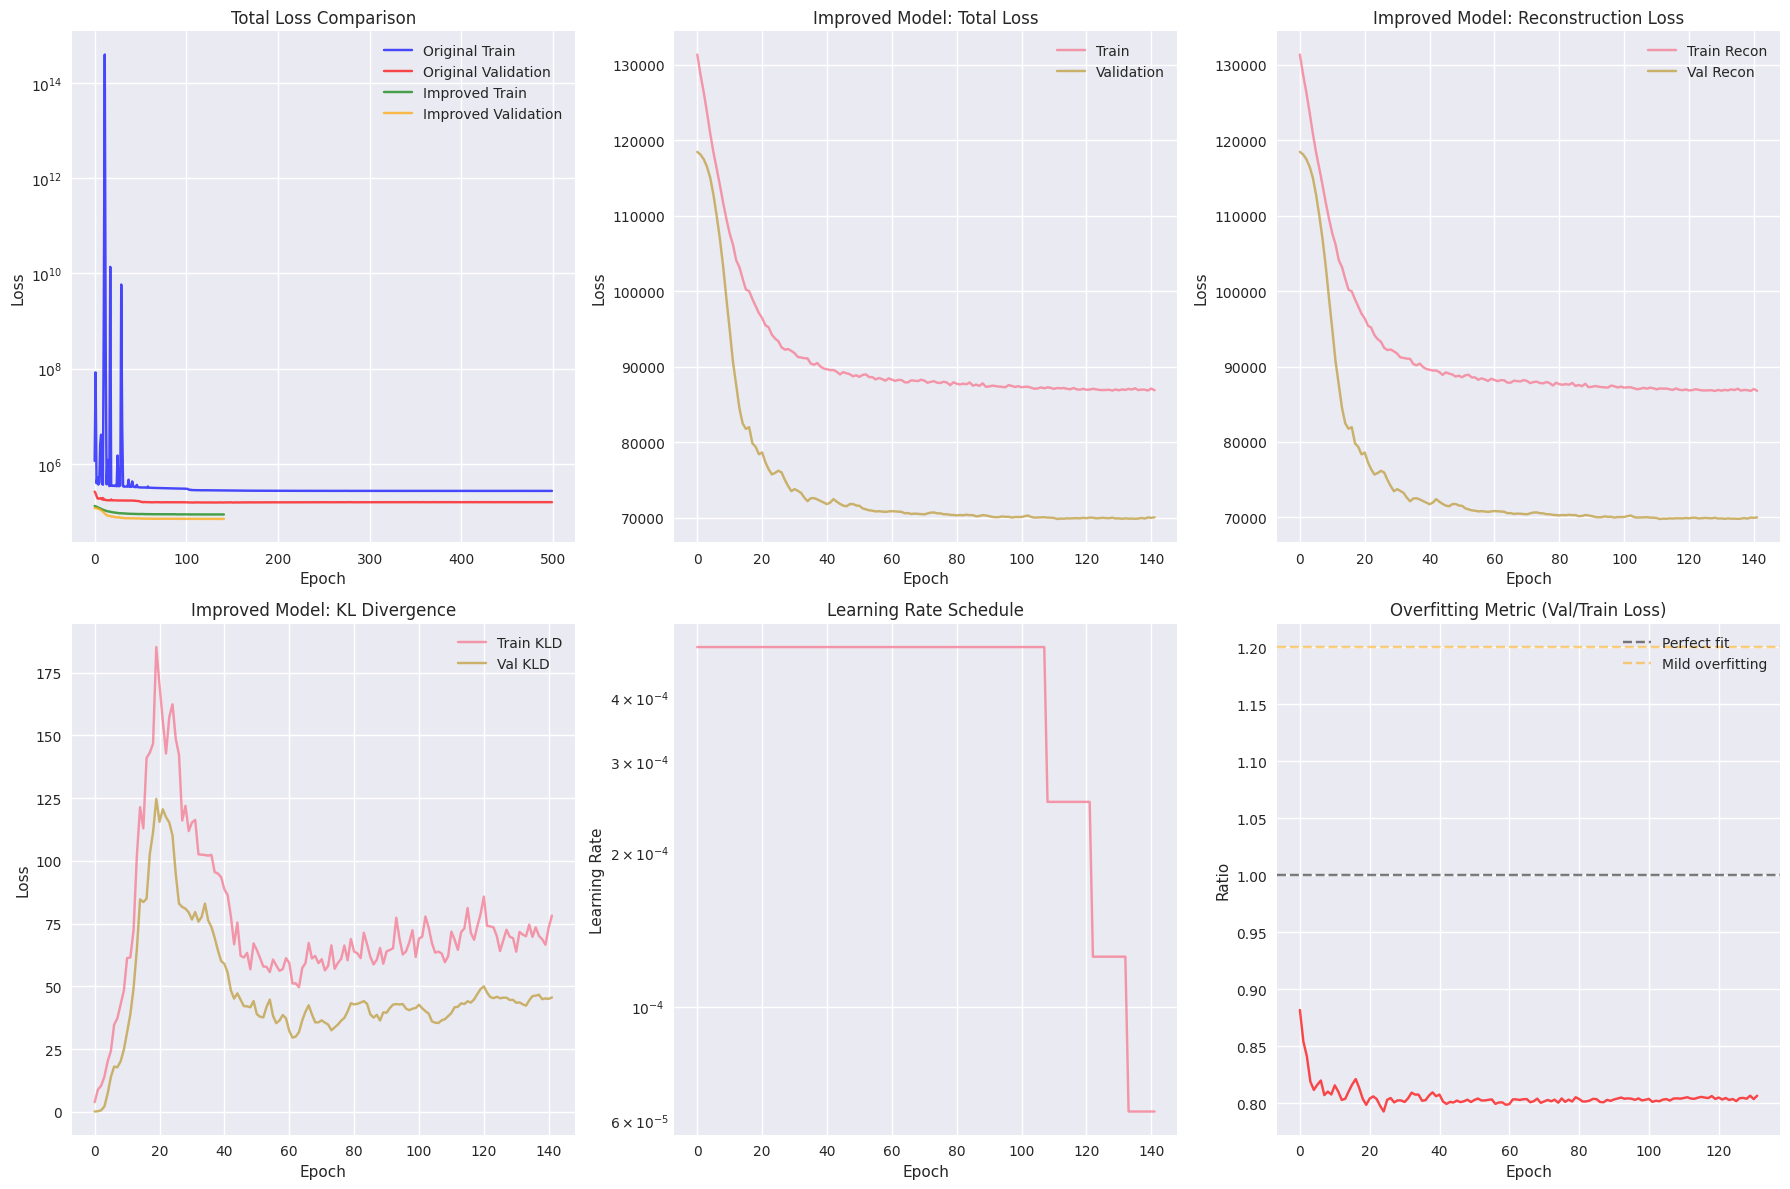


=== 性能改善の比較 ===

元のモデル最終検証損失: 157627.7969
改善版最終検証損失: 70071.3750
改善率: 55.55%

元のモデル最良検証損失: 154538.0781
改善版最良検証損失: 69848.5000
最良性能の改善率: 54.80%


In [51]:
# 改善版モデルの結果可視化と比較
print("\n=== 改善版モデルの結果分析 ===\n")

# ベストモデルをロード
checkpoint = torch.load('best_improved_vae_model.pth')
improved_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model loaded from epoch {checkpoint['epoch']} with validation loss: {checkpoint['loss']:.4f}")

# 損失の比較プロット
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 元のモデルと改善版の比較
epochs_orig = range(len(train_losses))
epochs_improved = range(len(improved_train_losses))

# 総損失の比較
axes[0, 0].plot(epochs_orig, train_losses, label='Original Train', alpha=0.7, color='blue')
axes[0, 0].plot(epochs_orig, val_losses, label='Original Validation', alpha=0.7, color='red')
axes[0, 0].plot(epochs_improved, improved_train_losses, label='Improved Train', alpha=0.7, color='green')
axes[0, 0].plot(epochs_improved, improved_val_losses, label='Improved Validation', alpha=0.7, color='orange')
axes[0, 0].set_title('Total Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 0].set_yscale('log')

# 改善版の詳細な損失推移
axes[0, 1].plot(improved_train_losses, label='Train', alpha=0.7)
axes[0, 1].plot(improved_val_losses, label='Validation', alpha=0.7)
axes[0, 1].set_title('Improved Model: Total Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 改善版の再構成損失
axes[0, 2].plot(improved_train_recon_losses, label='Train Recon', alpha=0.7)
axes[0, 2].plot(improved_val_recon_losses, label='Val Recon', alpha=0.7)
axes[0, 2].set_title('Improved Model: Reconstruction Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 改善版のKL損失
axes[1, 0].plot(improved_train_kld_losses, label='Train KLD', alpha=0.7)
axes[1, 0].plot(improved_val_kld_losses, label='Val KLD', alpha=0.7)
axes[1, 0].set_title('Improved Model: KL Divergence')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# 学習率の推移
axes[1, 1].plot(improved_learning_rates, alpha=0.7)
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].grid(True)
axes[1, 1].set_yscale('log')

# 過学習の指標（Train/Val loss ratio）
if len(improved_val_losses) > 10:
    overfitting_metric = np.array(improved_val_losses[10:]) / np.array(improved_train_losses[10:])
    axes[1, 2].plot(overfitting_metric, alpha=0.7, color='red')
    axes[1, 2].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Perfect fit')
    axes[1, 2].axhline(y=1.2, color='orange', linestyle='--', alpha=0.5, label='Mild overfitting')
    axes[1, 2].set_title('Overfitting Metric (Val/Train Loss)')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Ratio')
    axes[1, 2].legend()
    axes[1, 2].grid(True)
    
    final_ratio = overfitting_metric[-1]
    if final_ratio < 1.1:
        overfitting_status = "良好 (No overfitting)"
    elif final_ratio < 1.3:
        overfitting_status = "軽微 (Mild overfitting)"
    else:
        overfitting_status = "深刻 (Severe overfitting)"
    
    print(f"最終的な過学習指標: {final_ratio:.3f} - {overfitting_status}")

plt.tight_layout()
plt.show()

# 性能改善の定量評価
if len(val_losses) > 0 and len(improved_val_losses) > 0:
    original_final_val = val_losses[-1]
    improved_final_val = improved_val_losses[-1]
    improvement = (original_final_val - improved_final_val) / original_final_val * 100
    
    print(f"\n=== 性能改善の比較 ===\n")
    print(f"元のモデル最終検証損失: {original_final_val:.4f}")
    print(f"改善版最終検証損失: {improved_final_val:.4f}")
    print(f"改善率: {improvement:.2f}%")
    
    # 最小検証損失の比較
    original_best_val = min(val_losses)
    improved_best_val = min(improved_val_losses)
    best_improvement = (original_best_val - improved_best_val) / original_best_val * 100
    
    print(f"\n元のモデル最良検証損失: {original_best_val:.4f}")
    print(f"改善版最良検証損失: {improved_best_val:.4f}")
    print(f"最良性能の改善率: {best_improvement:.2f}%")

Best classifier: SVM (Test Accuracy: 0.5000)


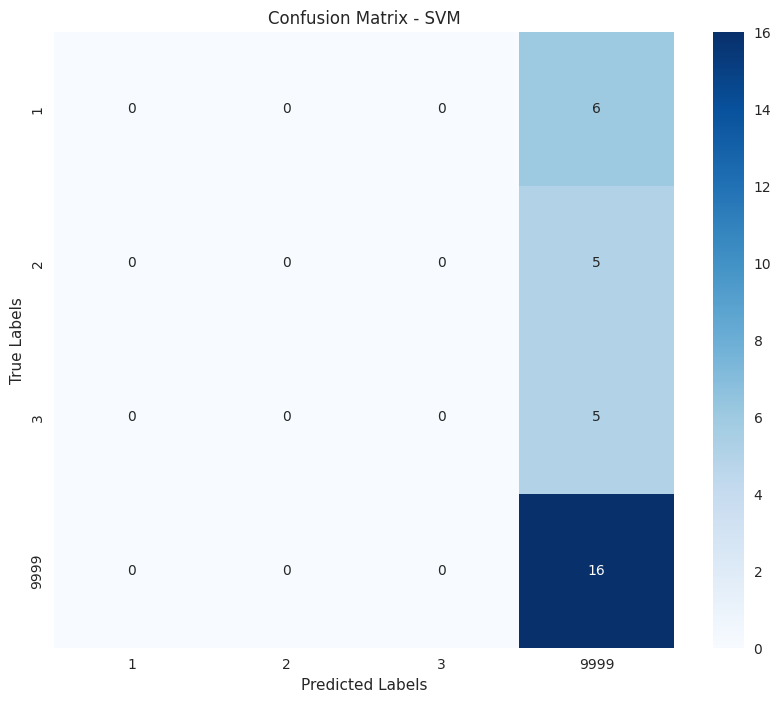

Final results saved to 'conv2d_vae_final_results.pth'


In [52]:
# 最良の分類器の混同行列を可視化
best_classifier = max(results.items(), key=lambda x: x[1]['test_accuracy'])
best_name, best_result = best_classifier

print(f"Best classifier: {best_name} (Test Accuracy: {best_result['test_accuracy']:.4f})")

# 混同行列の可視化
cm = confusion_matrix(y_test, best_result['predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=np.unique(labels_array), 
           yticklabels=np.unique(labels_array))
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# モデルの保存
final_results = {
    'model_state_dict': model.state_dict(),
    'features': features,
    'labels': labels_array,
    'classification_results': results,
    'data_shape_info': {
        'n_channels': n_channels,
        'n_scales': n_scales,
        'n_times': n_times,
        'latent_dim': latent_dim
    }
}

torch.save(final_results, 'conv2d_vae_final_results.pth')
print("Final results saved to 'conv2d_vae_final_results.pth'")